# Importing important packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

import pyodbc

## Connecting to sql server to import data

In [2]:
# Finding ODBC Driver

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [3]:
# ============================================================
# 1. SQL Server connection
# ============================================================

server = r"DESKTOP-0SIEUH6\SQLEXPRESS"
database = "LogisticsAnalyticsDB"

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

# ============================================================
# 2. Get all tables from dbo schema
# ============================================================

tables_query = """
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_SCHEMA = 'dbo'
  AND TABLE_TYPE = 'BASE TABLE'
ORDER BY TABLE_NAME;
"""

tables = pd.read_sql(tables_query, conn)

print("Tables found:")
print(tables)

Tables found:
       TABLE_NAME
0    Dim_Carriers
1   Dim_Customers
2       Dim_Dates
3   Dim_Employees
4   Dim_Locations
5    Dim_Products
6      Dim_Routes
7    Dim_Vehicles
8  Dim_Warehouses
9  Fact_Shipments


## Importing datasets from sql server in form of tables

In [5]:
# Dictionary to hold all DataFrames
dataframes = {}

for table_name in tables["TABLE_NAME"]:
    
    query = f"SELECT * FROM dbo.[{table_name}]"
    
    dataframes[table_name] = pd.read_sql(query, conn)
    
    # Create a variable with the same name as the SQL table
    globals()[table_name] = dataframes[table_name]
    
    print(f"{table_name}: {dataframes[table_name].shape}")

Dim_Carriers: (10, 5)
Dim_Customers: (3000, 6)
Dim_Dates: (1096, 10)
Dim_Employees: (900, 5)
Dim_Locations: (25, 6)
Dim_Products: (800, 7)
Dim_Routes: (350, 6)
Dim_Vehicles: (500, 6)
Dim_Warehouses: (30, 6)
Fact_Shipments: (22110, 30)


In [7]:
Fact_Shipments

,ShipmentID,DateKey,CustomerID,ProductID,CarrierID,VehicleID,WarehouseID,EmployeeID,RouteID,ShipmentStatus,...,OrderValue,HandlingTimeHours,LoadingTimeHours,WarehouseProcessingTimeHours,FuelConsumptionLiters,PromisedDeliveryDays,ActualDeliveryDays,DeliveryTimeHours,NumPreviousDelaysCustomer,Late_Delivery
0,1,20240816,1690,456,9,315,7,816.0,27,Delivered,...,6795.59,0.11,0.83,1.96,167.59,2,1,24.2,1,False
1,2,20220209,2755,785,2,74,23,549.0,303,Delivered,...,6048.13,1.42,0.87,5.08,156.02,3,2,48.0,2,False
2,3,20221024,2601,376,10,56,22,676.0,147,Returned,...,2420.39,1.04,0.90,2.88,189.48,5,4,98.3,1,False
3,4,20241113,1104,198,5,53,10,553.0,177,Delivered,...,4946.62,2.28,1.89,4.48,412.75,1,6,150.2,0,True
4,5,20240607,2129,354,8,150,25,254.0,333,Delivered,...,6212.62,2.03,1.86,1.79,241.47,6,9,218.5,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22105,22106,20230211,2565,269,4,307,3,529.0,71,Delivered,...,8256.59,2.20,1.59,2.04,236.27,5,4,97.8,0,False
22106,22107,20220907,387,261,7,303,4,160.0,326,Delivered,...,6049.86,1.56,0.95,NaN,322.46,6,10,229.6,4,True
22107,22108,20241226,642,423,6,486,6,23.0,116,Delivered,...,1808.42,0.92,0.50,2.22,324.61,5,10,256.6,2,True
22108,22109,20240315,790,742,3,484,5,25.0,101,Delivered,...,3948.63,1.09,1.72,2.72,164.23,4,4,96.4,4,False


######
# Q1. Does shipping priority affect delivery performance?

#### How does shipping priority influence delivery performance, and are higher-priority shipments actually delivered closer to their promised delivery time?

In [14]:
# Createing the delivery performance metrics:
# - Total shipments
# - Late delivery %
# - Average promised delivery days
# - Average actual delivery days
# - Average delay days

priority_summary = (
    Fact_Shipments
    .groupby("ShippingPriority")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean")
    )
    .reset_index()
)

priority_summary["Late_Delivery_Rate"] = (
    priority_summary["Late_Delivery_Rate"] * 100
)

priority_summary["Avg_Delay_Days"] = (
    priority_summary["Avg_Actual_Days"]
    - priority_summary["Avg_Promised_Days"]
)



# Clean up the summary

priority_summary = priority_summary.round({
    "Late_Delivery_Rate": 2,
    "Avg_Promised_Days": 2,
    "Avg_Actual_Days": 2,
    "Avg_Delay_Days": 2
})

,ShippingPriority,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days
0,Express,6733,1016,15.089856,3.015595,3.487004,0.471409
1,Same-Day,2243,569,25.367811,1.000000,2.617031,1.617031
2,Standard,13134,1669,12.707477,4.717755,5.008147,0.290391


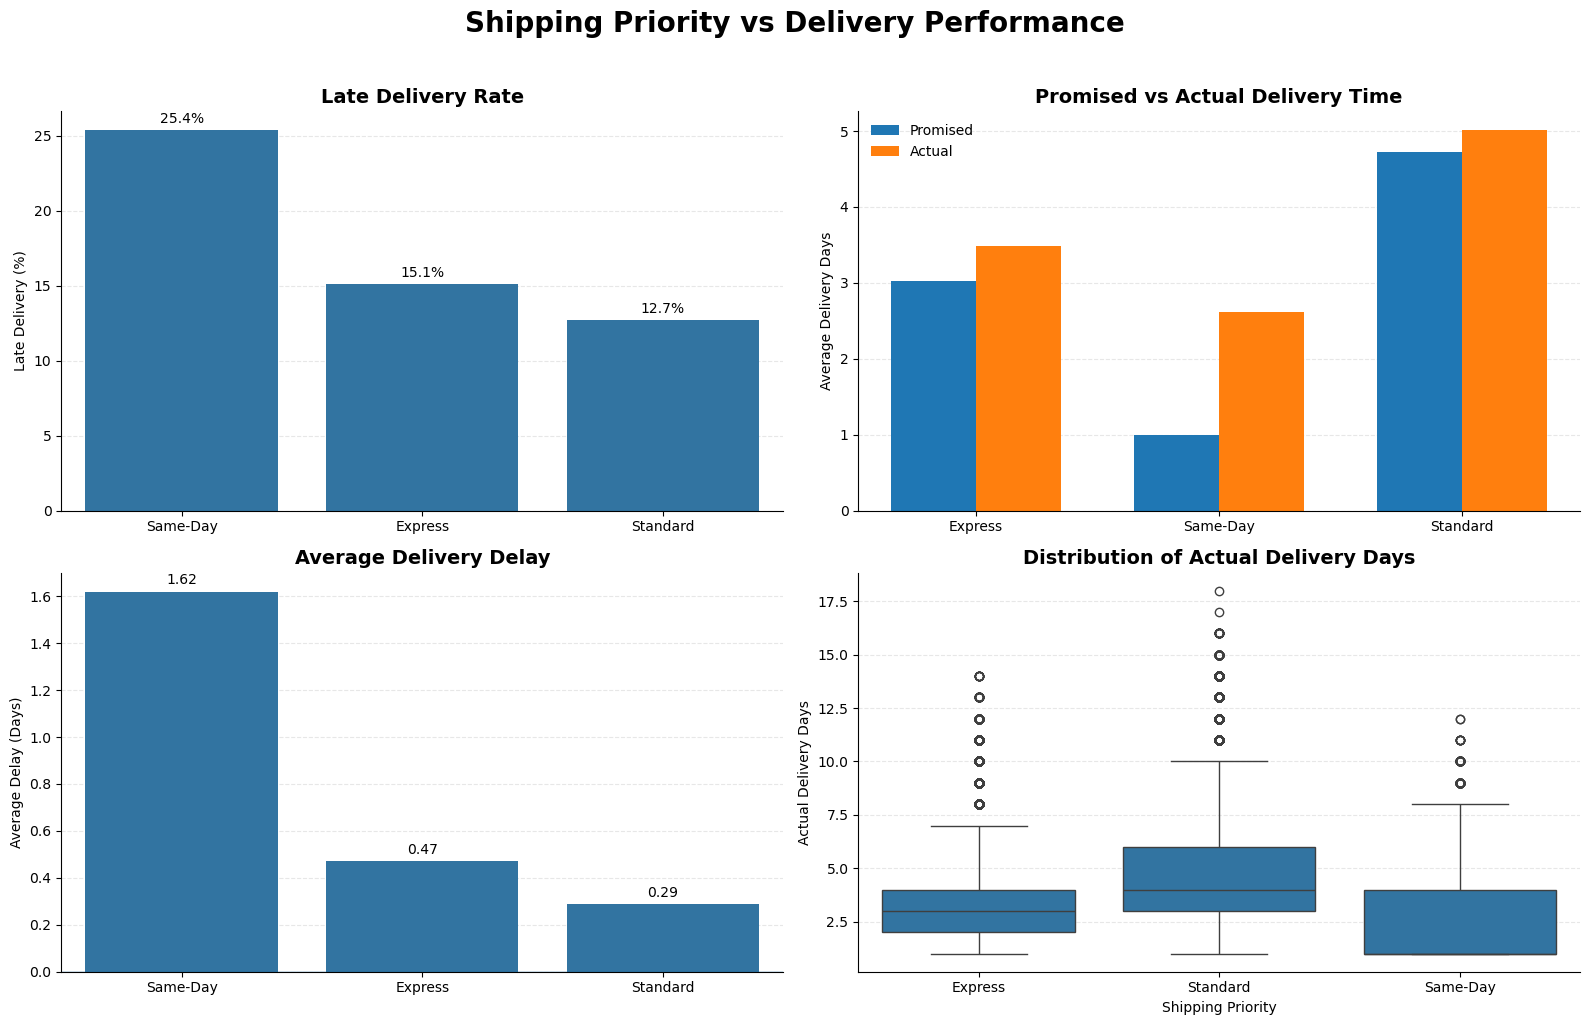

In [24]:
# ============================================================
# 2. Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

fig.suptitle(
    "Shipping Priority vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Late Delivery Rate
# ------------------------------------------------------------

plot_data = priority_summary.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

ax = sns.barplot(
    data=plot_data,
    x="ShippingPriority",
    y="Late_Delivery_Rate",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 2. Promised vs Actual Delivery Days
# ------------------------------------------------------------

x = np.arange(len(priority_summary))
width = 0.35

axes[0, 1].bar(
    x - width / 2,
    priority_summary["Avg_Promised_Days"],
    width,
    label="Promised"
)

axes[0, 1].bar(
    x + width / 2,
    priority_summary["Avg_Actual_Days"],
    width,
    label="Actual"
)

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(
    priority_summary["ShippingPriority"]
)

axes[0, 1].set_title(
    "Promised vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Average Delivery Days")

axes[0, 1].legend(
    frameon=False
)


# ------------------------------------------------------------
# 3. Average Delivery Delay
# ------------------------------------------------------------

plot_data = priority_summary.sort_values(
    "Avg_Delay_Days",
    ascending=False
)

ax = sns.barplot(
    data=plot_data,
    x="ShippingPriority",
    y="Avg_Delay_Days",
    ax=axes[1, 0]
)

axes[1, 0].axhline(
    0,
    linewidth=1
)

axes[1, 0].set_title(
    "Average Delivery Delay",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Delay (Days)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )


# ------------------------------------------------------------
# 4. Distribution of Actual Delivery Days
# ------------------------------------------------------------

sns.boxplot(
    data=Fact_Shipments,
    x="ShippingPriority",
    y="ActualDeliveryDays",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Distribution of Actual Delivery Days",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Shipping Priority")
axes[1, 1].set_ylabel("Actual Delivery Days")


# ============================================================
# Overall Formatting
# ============================================================

for ax in axes.flat:

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add subtle horizontal grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # Keep grid behind the plots
    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q2. — Do longer routes experience higher delivery delays?

#### How does route distance affect delivery performance, and are shipments traveling longer distances more likely to be delivered late?

In [25]:
# Create distance categories using quartiles
Fact_Shipments["Distance_Band"] = pd.qcut(
    Fact_Shipments["DistanceKm"],
    q=4,
    labels=[
        "Short Distance",
        "Medium Distance",
        "Long Distance",
        "Very Long Distance"
    ]
)

# Calculate delivery performance for each distance band
distance_summary = (
    Fact_Shipments
    .groupby("Distance_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Distance_Km=("DistanceKm", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean")
    )
    .reset_index()
)

# Calculate average delay
distance_summary["Avg_Delay_Days"] = (
    distance_summary["Avg_Actual_Days"]
    - distance_summary["Avg_Promised_Days"]
)

# Convert late delivery rate to percentage
distance_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
distance_summary = distance_summary.round(2)

distance_summary

,Distance_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Distance_Km,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days
0,Short Distance,5528,288,5.21,495.08,2.37,2.22,-0.15
1,Medium Distance,5529,513,9.28,1045.06,3.42,3.52,0.10
2,Long Distance,5525,1043,18.88,1535.85,4.32,5.07,0.75
3,Very Long Distance,5528,1410,25.51,2010.37,5.18,6.41,1.23


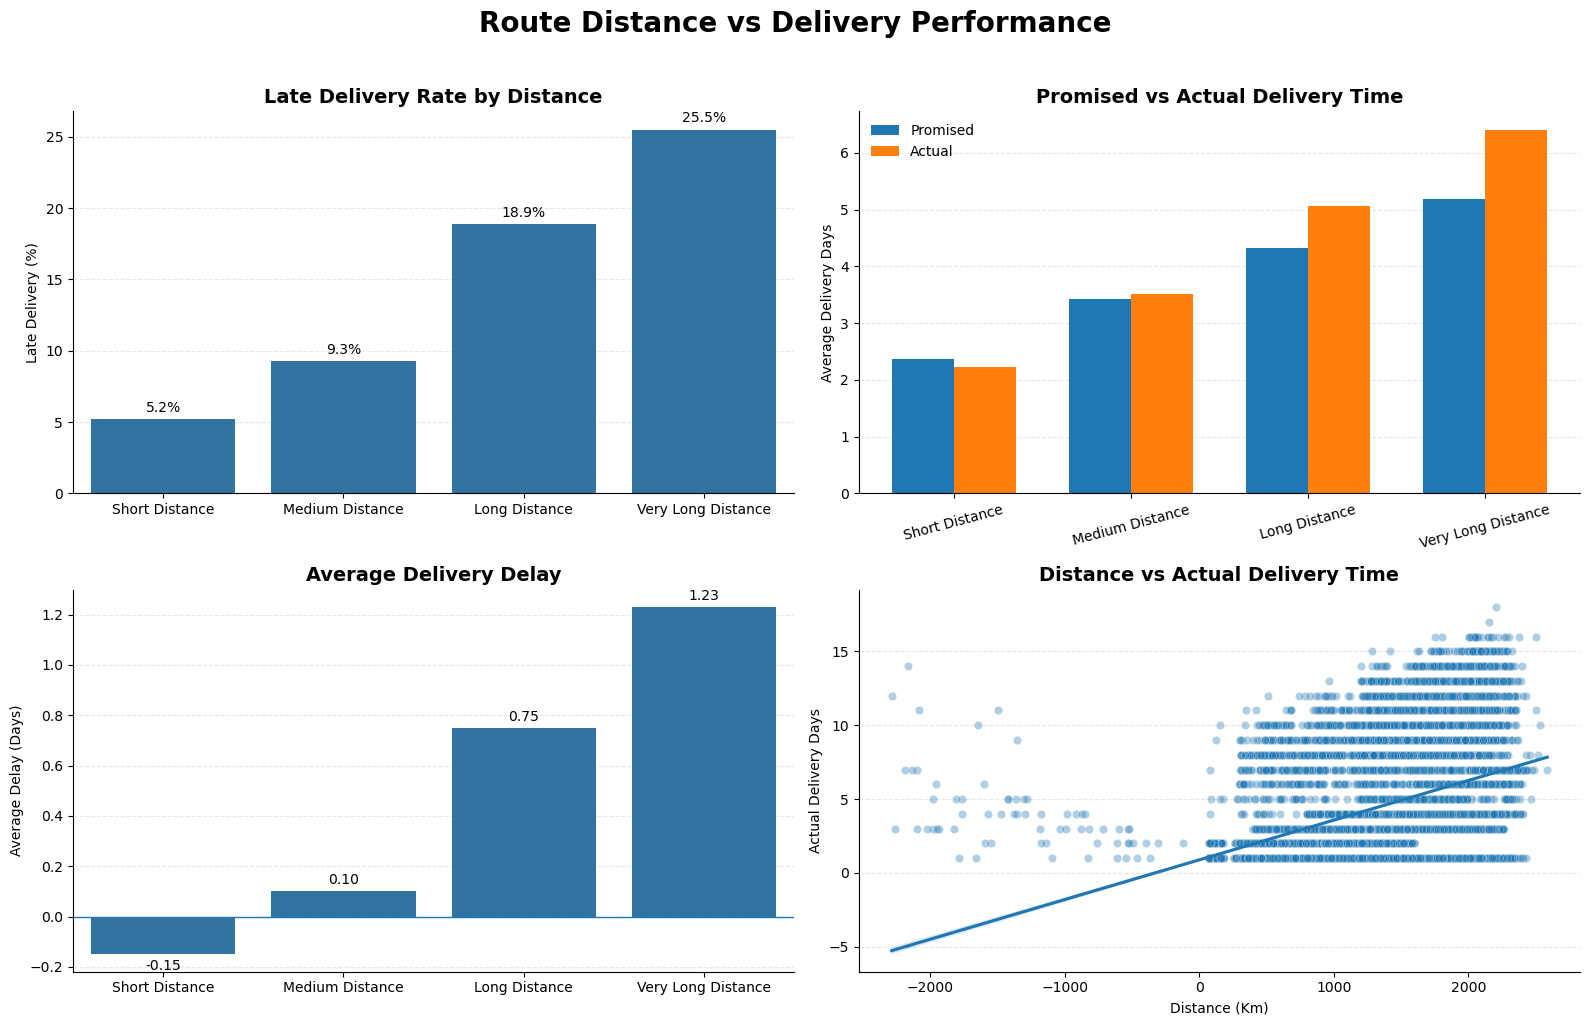

In [26]:
# ============================================================
# Create 2 × 2 visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

fig.suptitle(
    "Route Distance vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Late Delivery Rate by Distance Band
# ------------------------------------------------------------

ax = sns.barplot(
    data=distance_summary,
    x="Distance_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Late Delivery Rate by Distance",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 2. Promised vs Actual Delivery Days
# ------------------------------------------------------------

x = np.arange(len(distance_summary))
width = 0.35

axes[0, 1].bar(
    x - width / 2,
    distance_summary["Avg_Promised_Days"],
    width,
    label="Promised"
)

axes[0, 1].bar(
    x + width / 2,
    distance_summary["Avg_Actual_Days"],
    width,
    label="Actual"
)

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(
    distance_summary["Distance_Band"],
    rotation=15
)

axes[0, 1].set_title(
    "Promised vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Average Delivery Days")

axes[0, 1].legend(
    frameon=False
)


# ------------------------------------------------------------
# 3. Average Delay by Distance
# ------------------------------------------------------------

ax = sns.barplot(
    data=distance_summary,
    x="Distance_Band",
    y="Avg_Delay_Days",
    ax=axes[1, 0]
)

axes[1, 0].axhline(
    0,
    linewidth=1
)

axes[1, 0].set_title(
    "Average Delivery Delay",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Delay (Days)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )


# ------------------------------------------------------------
# 4. Distance vs Actual Delivery Days
# ------------------------------------------------------------

sns.scatterplot(
    data=Fact_Shipments,
    x="DistanceKm",
    y="ActualDeliveryDays",
    alpha=0.35,
    ax=axes[1, 1]
)

# Add trend line
sns.regplot(
    data=Fact_Shipments,
    x="DistanceKm",
    y="ActualDeliveryDays",
    scatter=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Distance vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Distance (Km)")
axes[1, 1].set_ylabel("Actual Delivery Days")


# ============================================================
# Overall Formatting
# ============================================================

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q3 — How does traffic and weather affect late deliveries?

#### To what extent do traffic and weather conditions influence delivery performance, and which combinations of conditions are associated with higher late-delivery rates?

In [27]:
# Create a helper function for delivery performance summary
def delivery_summary(data, group_cols):
    
    summary = (
        data
        .groupby(group_cols, observed=True)
        .agg(
            Total_Shipments=("ShipmentID", "count"),
            Late_Shipments=("Late_Delivery", "sum"),
            Late_Delivery_Rate=("Late_Delivery", "mean"),
            Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
            Avg_Delay_Days=(
                "ActualDeliveryDays",
                lambda x: (
                    x - data.loc[x.index, "PromisedDeliveryDays"]
                ).mean()
            )
        )
        .reset_index()
    )
    
    # Convert late delivery rate to percentage
    summary["Late_Delivery_Rate"] *= 100
    
    return summary.round(2)


# ------------------------------------------------------------
# 1. Traffic condition summary
# ------------------------------------------------------------

traffic_summary = delivery_summary(
    Fact_Shipments,
    ["TrafficCondition"]
)

traffic_summary

,TrafficCondition,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Delivery_Days,Avg_Delay_Days
0,HIGH,92,21,22.83,4.71,1.08
1,High,5455,1286,23.57,4.92,1.11
2,LOW,109,11,10.09,4.17,0.05
3,Low,7532,729,9.68,3.97,0.13
4,Medium,8792,1192,13.56,4.20,0.39
5,med,130,15,11.54,4.22,0.35


In [28]:
# ------------------------------------------------------------
# 2. Weather condition summary
# ------------------------------------------------------------

weather_summary = delivery_summary(
    Fact_Shipments,
    ["WeatherCondition"]
)

weather_summary

,WeatherCondition,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Delivery_Days,Avg_Delay_Days
0,Clear,12034,1357,11.28,4.06,0.24
1,Extreme Heat,1731,191,11.03,4.04,0.24
2,Fog,2197,414,18.84,4.50,0.73
3,Rain,4341,778,17.92,4.55,0.71
4,Storm,1475,467,31.66,5.57,1.71


In [31]:
# ------------------------------------------------------------
# 3. Combined traffic and weather analysis
# ------------------------------------------------------------

traffic_weather_summary = delivery_summary(
    Fact_Shipments,
    ["TrafficCondition", "WeatherCondition"]
)


# Sorting this
traffic_weather_summary = (
    traffic_weather_summary
    .sort_values(
        "Late_Delivery_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

traffic_weather_summary

,TrafficCondition,WeatherCondition,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Delivery_Days,Avg_Delay_Days
0,HIGH,Storm,5,4,80.00,8.20,4.20
1,High,Storm,369,210,56.91,7.55,3.68
2,High,Rain,1073,384,35.79,5.81,1.97
3,HIGH,Extreme Heat,9,3,33.33,6.00,2.22
4,HIGH,Fog,10,3,30.00,5.00,1.40
5,HIGH,Rain,11,3,27.27,4.18,1.18
6,High,Fog,497,132,26.56,4.99,1.27
7,Medium,Storm,583,150,25.73,5.06,1.24
8,med,Storm,8,2,25.00,5.38,1.00
9,Low,Storm,505,101,20.00,4.70,0.83


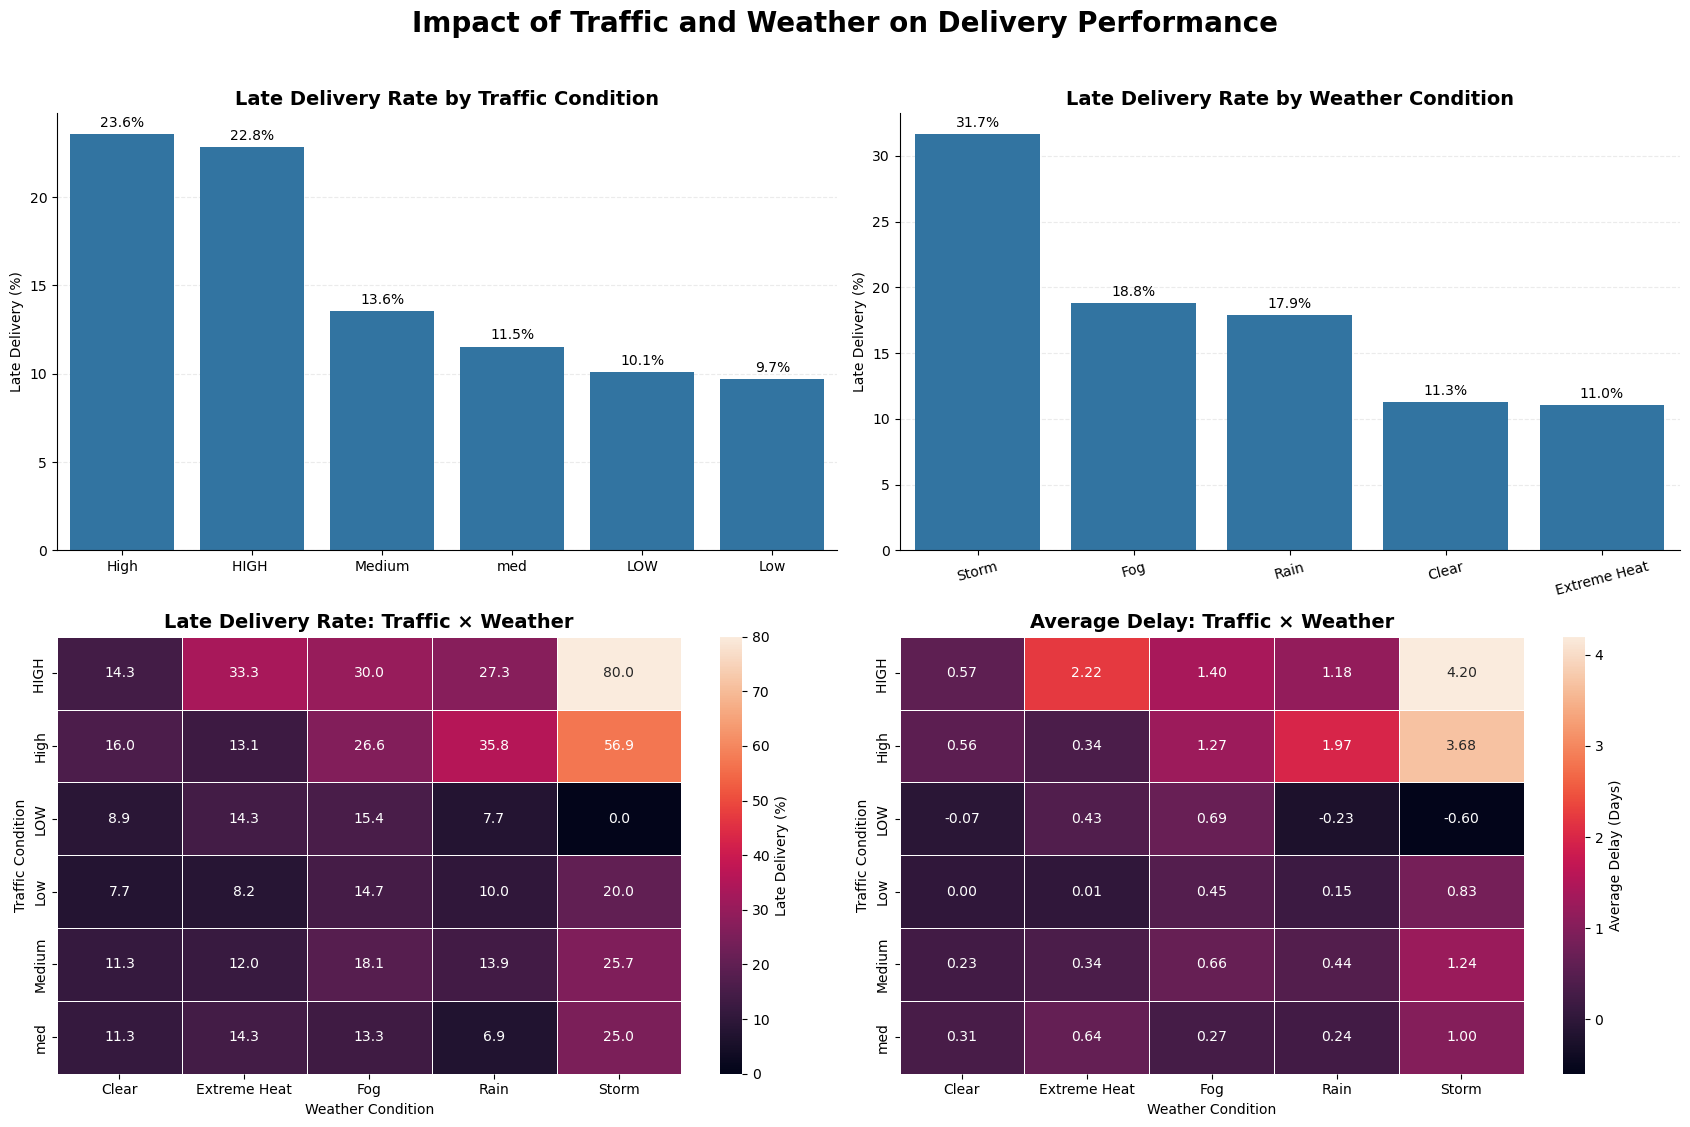

In [32]:
# ============================================================
# 2 × 2 Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 11)
)

fig.suptitle(
    "Impact of Traffic and Weather on Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Late Delivery Rate by Traffic Condition
# ------------------------------------------------------------

traffic_plot = traffic_summary.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

ax = sns.barplot(
    data=traffic_plot,
    x="TrafficCondition",
    y="Late_Delivery_Rate",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Late Delivery Rate by Traffic Condition",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 2. Late Delivery Rate by Weather Condition
# ------------------------------------------------------------

weather_plot = weather_summary.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

ax = sns.barplot(
    data=weather_plot,
    x="WeatherCondition",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Weather Condition",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Late Delivery (%)")

axes[0, 1].tick_params(
    axis="x",
    rotation=15
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 3. Traffic × Weather — Late Delivery Rate Heatmap
# ------------------------------------------------------------

heatmap_data = (
    traffic_weather_summary
    .pivot(
        index="TrafficCondition",
        columns="WeatherCondition",
        values="Late_Delivery_Rate"
    )
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Late Delivery (%)"},
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Late Delivery Rate: Traffic × Weather",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Weather Condition")
axes[1, 0].set_ylabel("Traffic Condition")


# ------------------------------------------------------------
# 4. Traffic × Weather — Average Delay Heatmap
# ------------------------------------------------------------

delay_heatmap = (
    traffic_weather_summary
    .pivot(
        index="TrafficCondition",
        columns="WeatherCondition",
        values="Avg_Delay_Days"
    )
)

sns.heatmap(
    delay_heatmap,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Average Delay (Days)"},
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Average Delay: Traffic × Weather",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Weather Condition")
axes[1, 1].set_ylabel("Traffic Condition")


# ============================================================
# Overall Formatting
# ============================================================

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q4 — Does Delivery Mode Affect Delivery Performance?

#### How does the selected delivery mode affect delivery reliability, delivery time, and the gap between promised and actual delivery days?

In [36]:
# Calculate delivery performance for each delivery mode
delivery_mode_summary = (
    Fact_Shipments
    .groupby("DeliveryMode")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean")
    )
    .reset_index()
)

# Convert late delivery rate into percentage
delivery_mode_summary["Late_Delivery_Rate"] *= 100

# Calculate the average gap between actual and promised delivery
delivery_mode_summary["Avg_Delay_Days"] = (
    delivery_mode_summary["Avg_Actual_Days"]
    - delivery_mode_summary["Avg_Promised_Days"]
)

# Round numerical values
delivery_mode_summary = delivery_mode_summary.round(2)

# Sort by late delivery rate
delivery_mode_summary = (
    delivery_mode_summary
    .sort_values(
        "Late_Delivery_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

delivery_mode_summary

,DeliveryMode,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days
0,rail,65,20,30.77,3.66,5.09,1.43
1,sea,20,5,25.00,3.40,4.45,1.05
2,Rail,3237,630,19.46,3.86,4.66,0.80
3,Sea,1021,194,19.00,3.81,4.63,0.83
4,road,290,42,14.48,3.75,4.29,0.54
5,Air,3263,446,13.67,3.77,4.16,0.39
6,Road,14144,1911,13.51,3.83,4.23,0.40
7,air,70,6,8.57,3.73,3.84,0.11


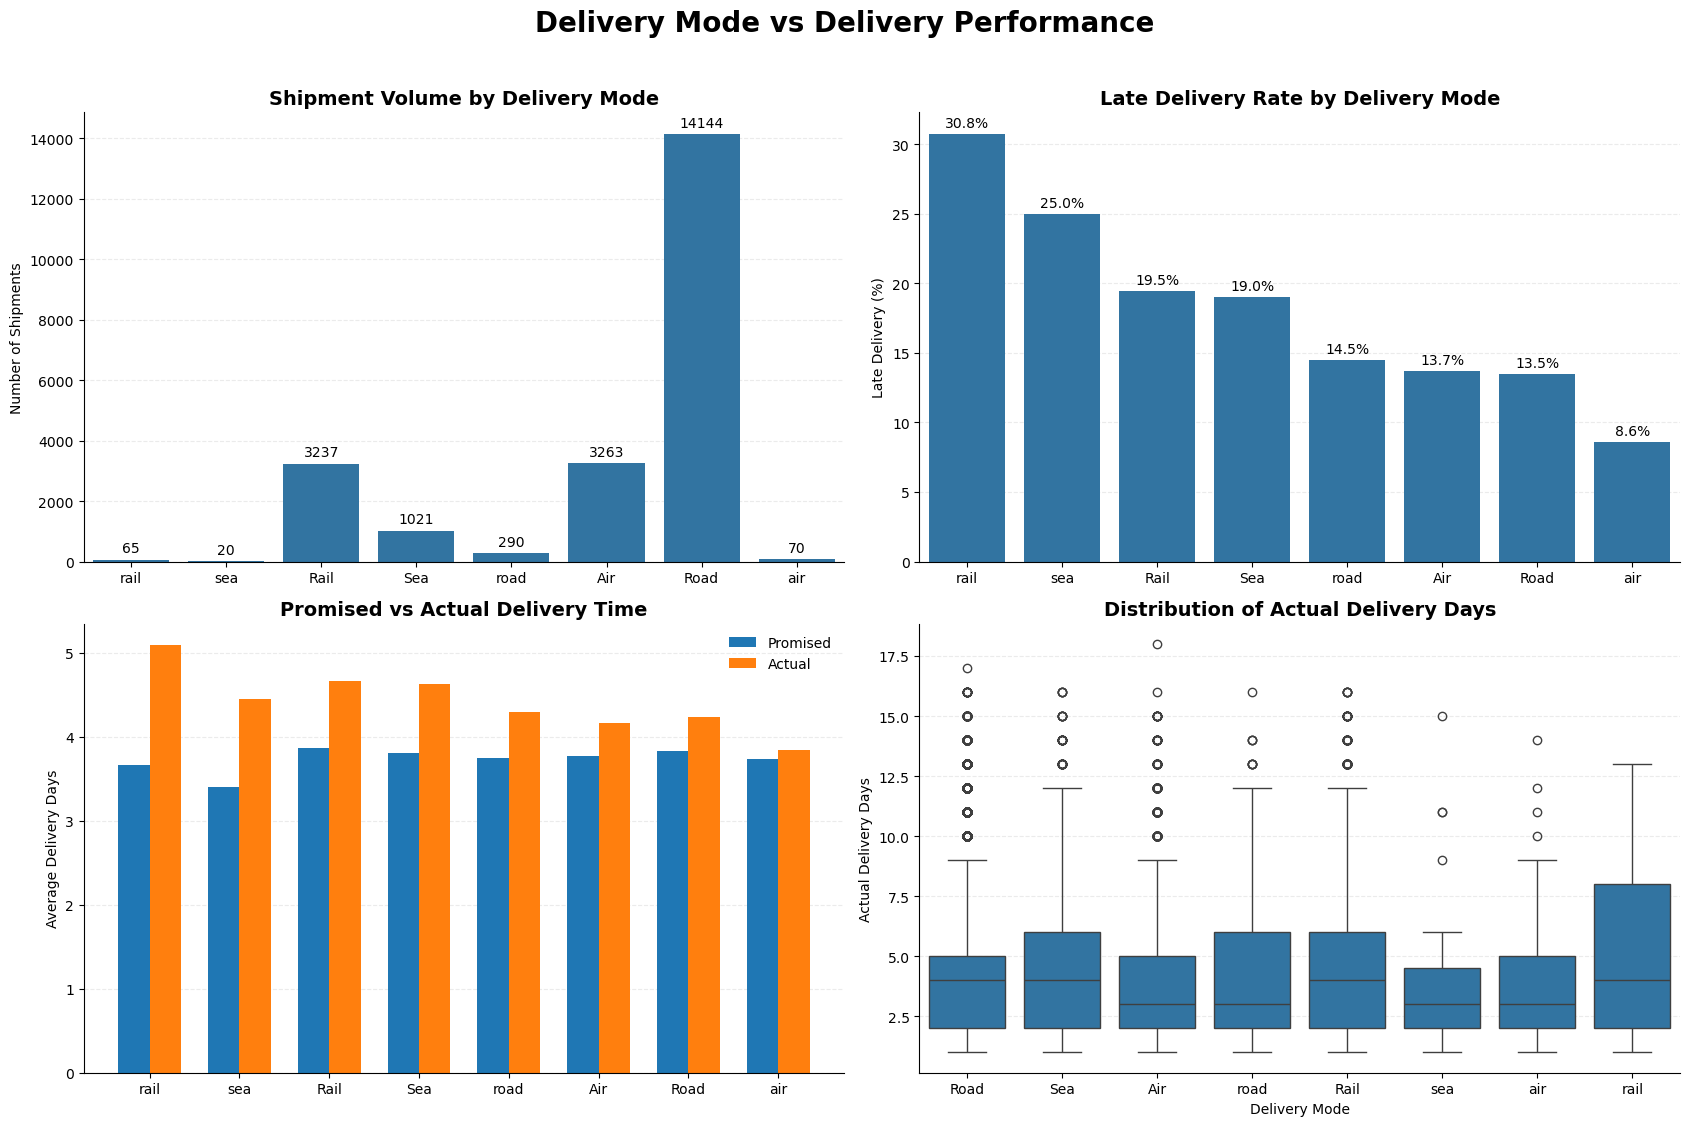

In [37]:
# ============================================================
# 2 × 2 Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 11)
)

fig.suptitle(
    "Delivery Mode vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Shipment Volume
# ------------------------------------------------------------

ax = sns.barplot(
    data=delivery_mode_summary,
    x="DeliveryMode",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Delivery Mode",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of Shipments")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )


# ------------------------------------------------------------
# 2. Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=delivery_mode_summary,
    x="DeliveryMode",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Delivery Mode",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 3. Promised vs Actual Delivery Days
# ------------------------------------------------------------

x = np.arange(len(delivery_mode_summary))
width = 0.35

axes[1, 0].bar(
    x - width / 2,
    delivery_mode_summary["Avg_Promised_Days"],
    width,
    label="Promised"
)

axes[1, 0].bar(
    x + width / 2,
    delivery_mode_summary["Avg_Actual_Days"],
    width,
    label="Actual"
)

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(
    delivery_mode_summary["DeliveryMode"]
)

axes[1, 0].set_title(
    "Promised vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Average Delivery Days")

axes[1, 0].legend(
    frameon=False
)


# ------------------------------------------------------------
# 4. Distribution of Actual Delivery Days
# ------------------------------------------------------------

sns.boxplot(
    data=Fact_Shipments,
    x="DeliveryMode",
    y="ActualDeliveryDays",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Distribution of Actual Delivery Days",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Delivery Mode")
axes[1, 1].set_ylabel("Actual Delivery Days")


# ============================================================
# Overall Formatting
# ============================================================

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q5 — Does customer history influence late deliveries?

#### Are customers with a history of previous delivery delays more likely to experience another late delivery?

In [39]:
# ============================================================
# Q5: Customer Delay History vs Current Delivery Performance
# ============================================================

# Create summary based on number of previous customer delays
customer_delay_summary = (
    Fact_Shipments
    .groupby("NumPreviousDelaysCustomer")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Actual_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delivery_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late delivery rate into percentage
customer_delay_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
customer_delay_summary = customer_delay_summary.round(2)

customer_delay_summary

,NumPreviousDelaysCustomer,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Actual_Delivery_Days,Avg_Delivery_Delay_Days
0,0,6608,840,12.71,4.15,0.34
1,1,8042,1082,13.45,4.21,0.38
2,2,4719,712,15.09,4.34,0.50
3,3,1967,452,22.98,4.88,1.09
4,4,609,125,20.53,4.79,0.92
5,5,133,36,27.07,5.07,1.20
6,6,25,5,20.00,5.04,0.84
7,7,5,1,20.00,3.60,0.60
8,8,2,1,50.00,6.00,2.50


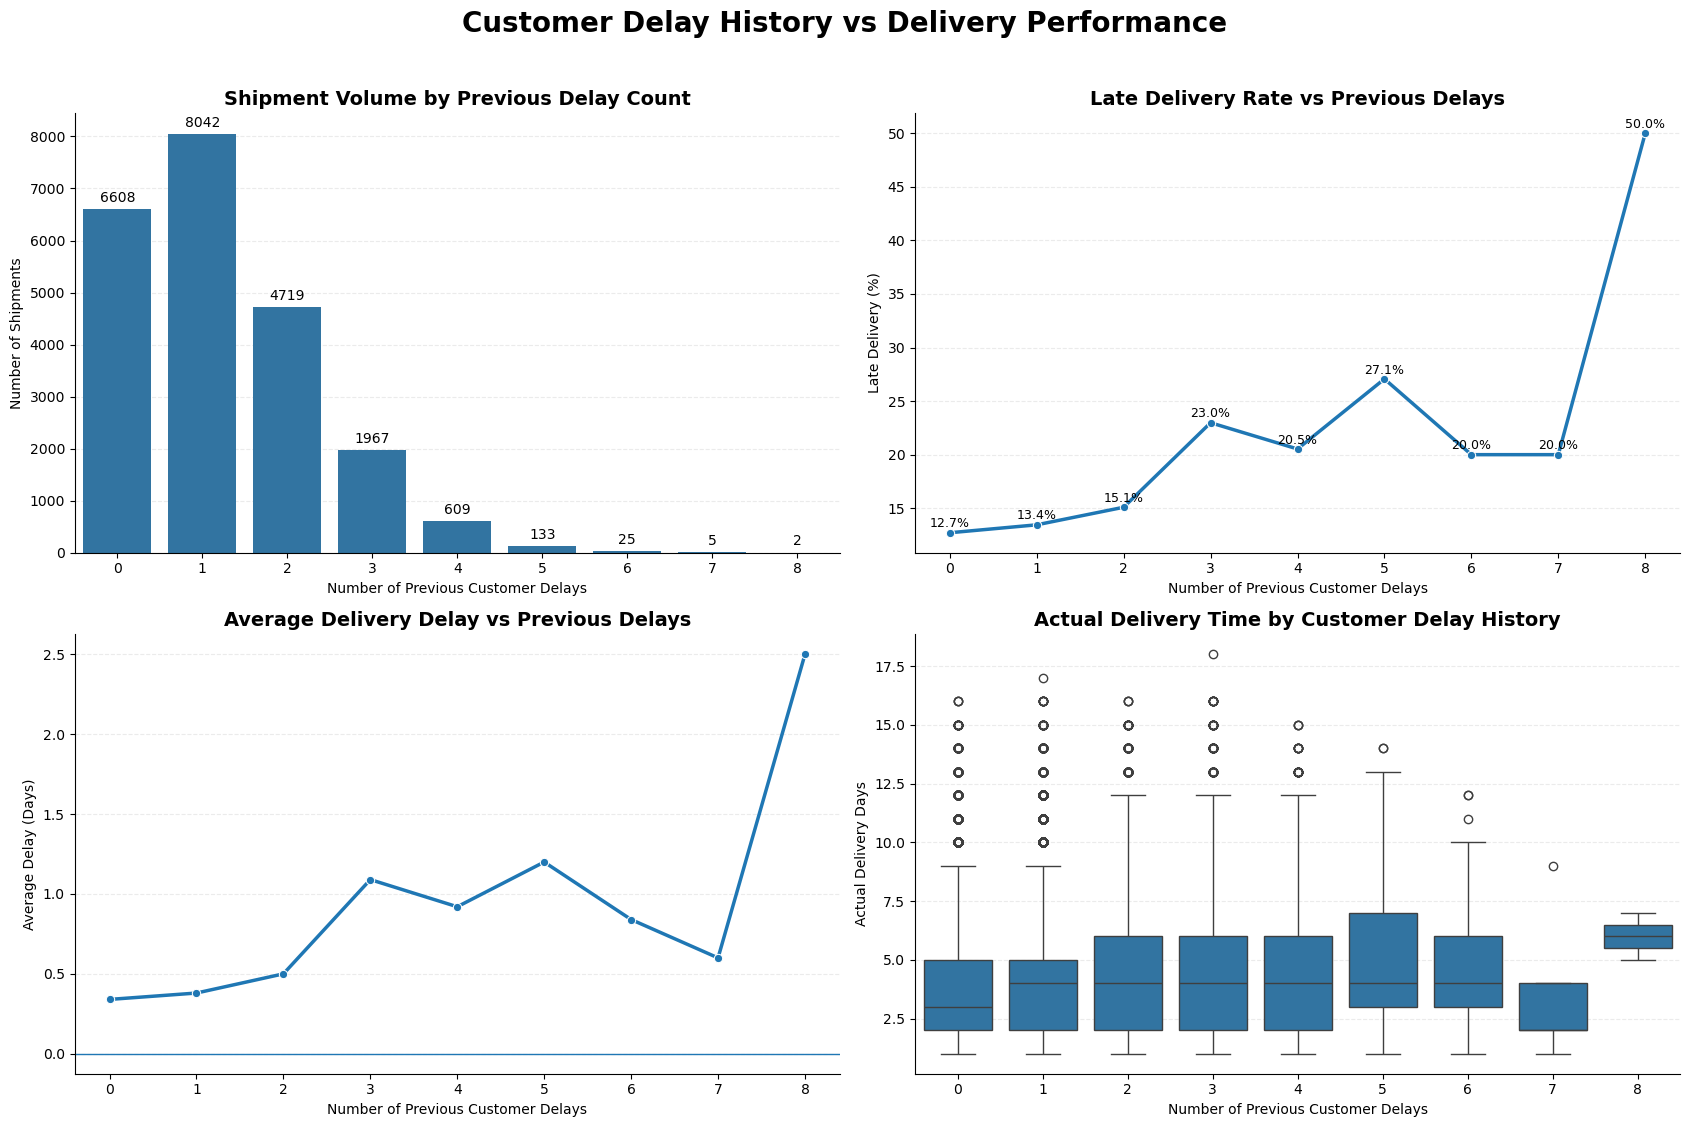

In [40]:
# ============================================================
# 2 × 2 Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 11)
)

fig.suptitle(
    "Customer Delay History vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Shipment Volume by Previous Delay Count
# ------------------------------------------------------------

ax = sns.barplot(
    data=customer_delay_summary,
    x="NumPreviousDelaysCustomer",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Previous Delay Count",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "Number of Previous Customer Delays"
)

axes[0, 0].set_ylabel(
    "Number of Shipments"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )


# ------------------------------------------------------------
# 2. Late Delivery Rate
# ------------------------------------------------------------

ax = sns.lineplot(
    data=customer_delay_summary,
    x="NumPreviousDelaysCustomer",
    y="Late_Delivery_Rate",
    marker="o",
    linewidth=2.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate vs Previous Delays",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Number of Previous Customer Delays"
)

axes[0, 1].set_ylabel(
    "Late Delivery (%)"
)

# Add percentage labels
for _, row in customer_delay_summary.iterrows():
    axes[0, 1].text(
        row["NumPreviousDelaysCustomer"],
        row["Late_Delivery_Rate"] + 0.5,
        f'{row["Late_Delivery_Rate"]:.1f}%',
        ha="center",
        fontsize=9
    )


# ------------------------------------------------------------
# 3. Average Delivery Delay
# ------------------------------------------------------------

ax = sns.lineplot(
    data=customer_delay_summary,
    x="NumPreviousDelaysCustomer",
    y="Avg_Delivery_Delay_Days",
    marker="o",
    linewidth=2.5,
    ax=axes[1, 0]
)

axes[1, 0].axhline(
    0,
    linewidth=1
)

axes[1, 0].set_title(
    "Average Delivery Delay vs Previous Delays",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Number of Previous Customer Delays"
)

axes[1, 0].set_ylabel(
    "Average Delay (Days)"
)


# ------------------------------------------------------------
# 4. Distribution of Actual Delivery Days
# ------------------------------------------------------------

sns.boxplot(
    data=Fact_Shipments,
    x="NumPreviousDelaysCustomer",
    y="ActualDeliveryDays",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Actual Delivery Time by Customer Delay History",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Number of Previous Customer Delays"
)

axes[1, 1].set_ylabel(
    "Actual Delivery Days"
)


# ============================================================
# Overall Formatting
# ============================================================

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q6 — Do heavier and larger packages take longer to deliver?

#### How do package weight and volume affect delivery time and the likelihood of late delivery?

In [41]:
# Create weight and volume bands using quartiles
Fact_Shipments["Weight_Band"] = pd.qcut(
    Fact_Shipments["PackageWeightKg"],
    q=4,
    labels=[
        "Light",
        "Medium",
        "Heavy",
        "Very Heavy"
    ]
)

Fact_Shipments["Volume_Band"] = pd.qcut(
    Fact_Shipments["PackageVolumeM3"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)


# ------------------------------------------------------------
# Weight summary
# ------------------------------------------------------------

weight_summary = (
    Fact_Shipments
    .groupby("Weight_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Weight_Kg=("PackageWeightKg", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean")
    )
    .reset_index()
)

weight_summary["Late_Delivery_Rate"] *= 100

weight_summary = weight_summary.round(2)


# ------------------------------------------------------------
# Volume summary
# ------------------------------------------------------------

volume_summary = (
    Fact_Shipments
    .groupby("Volume_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Volume_M3=("PackageVolumeM3", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean")
    )
    .reset_index()
)

volume_summary["Late_Delivery_Rate"] *= 100

volume_summary = volume_summary.round(2)


weight_summary

,Weight_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Weight_Kg,Avg_Actual_Days
0,Light,5421,772,14.24,7.17,4.28
1,Medium,5414,832,15.37,23.57,4.32
2,Heavy,5416,792,14.62,50.34,4.34
3,Very Heavy,5417,799,14.75,130.52,4.28


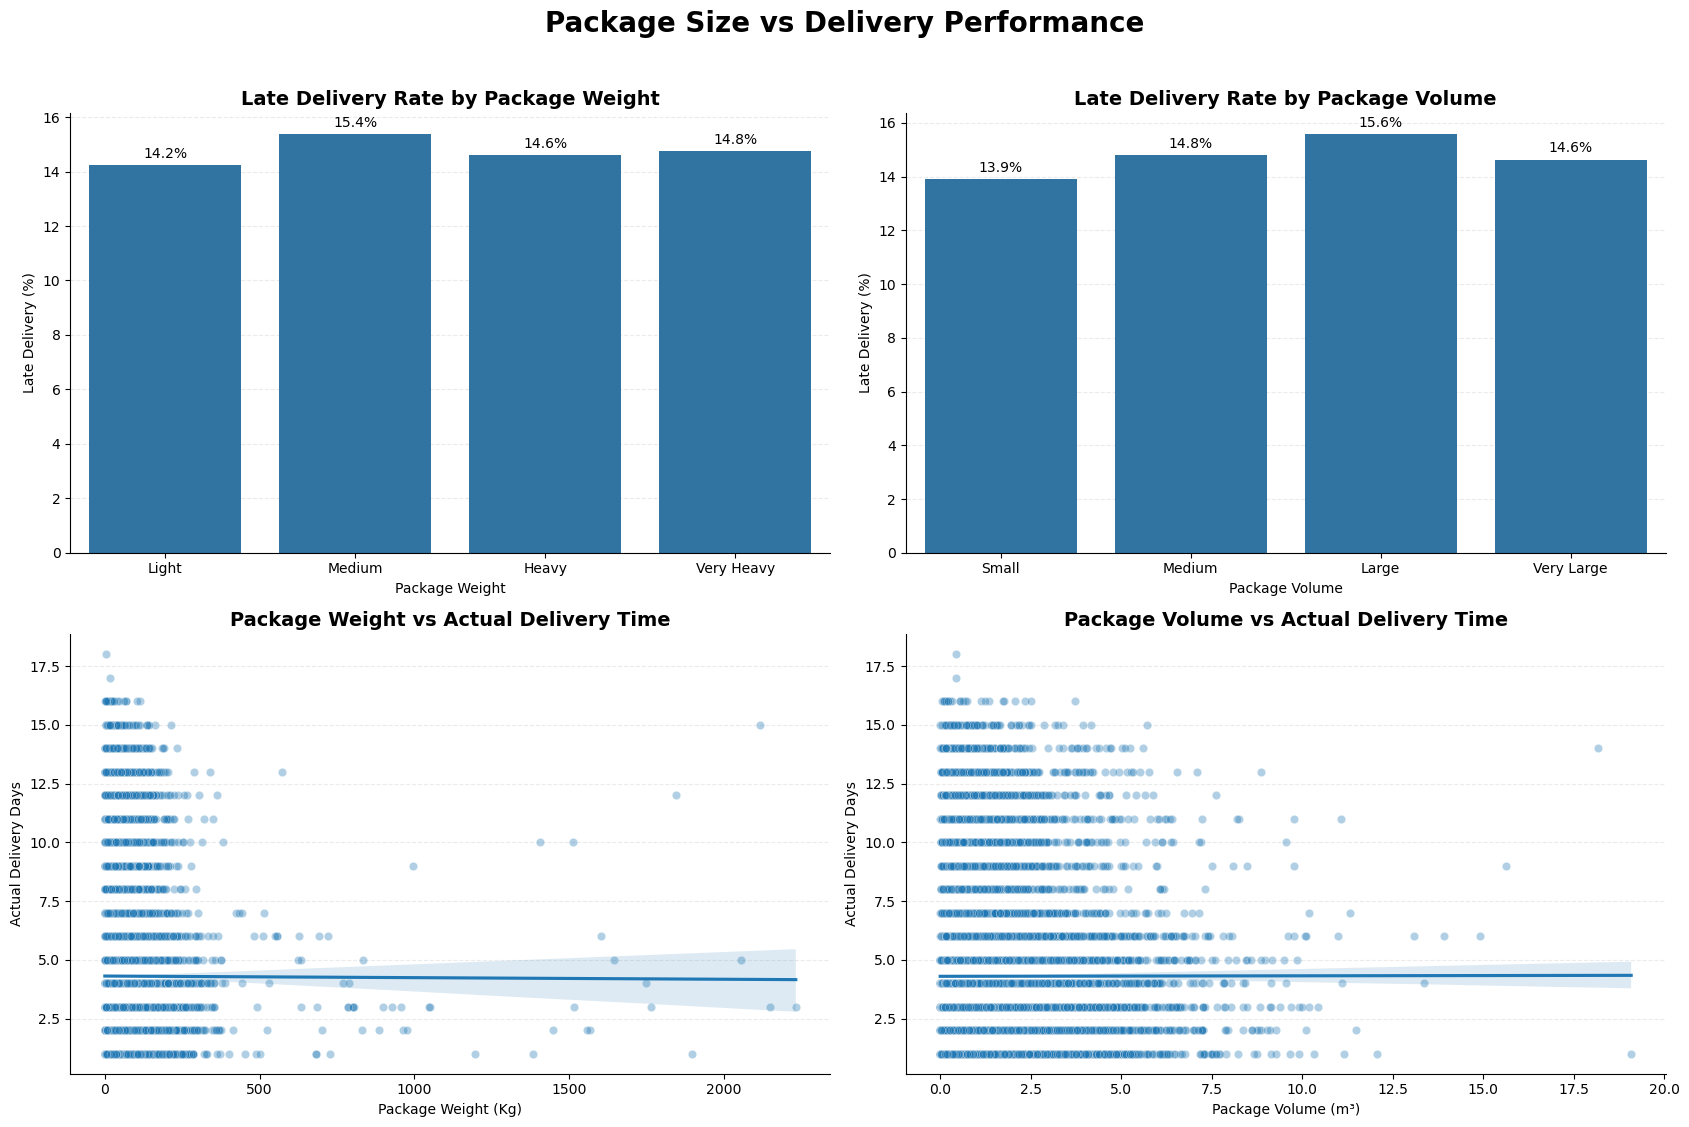

In [42]:
# ============================================================
# 2 × 2 Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 11)
)

fig.suptitle(
    "Package Size vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Weight vs Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=weight_summary,
    x="Weight_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Late Delivery Rate by Package Weight",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Package Weight")
axes[0, 0].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 2. Volume vs Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=volume_summary,
    x="Volume_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Package Volume",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Package Volume")
axes[0, 1].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 3. Package Weight vs Actual Delivery Days
# ------------------------------------------------------------

sns.scatterplot(
    data=Fact_Shipments,
    x="PackageWeightKg",
    y="ActualDeliveryDays",
    alpha=0.35,
    ax=axes[1, 0]
)

sns.regplot(
    data=Fact_Shipments,
    x="PackageWeightKg",
    y="ActualDeliveryDays",
    scatter=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Package Weight vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Package Weight (Kg)")
axes[1, 0].set_ylabel("Actual Delivery Days")


# ------------------------------------------------------------
# 4. Package Volume vs Actual Delivery Days
# ------------------------------------------------------------

sns.scatterplot(
    data=Fact_Shipments,
    x="PackageVolumeM3",
    y="ActualDeliveryDays",
    alpha=0.35,
    ax=axes[1, 1]
)

sns.regplot(
    data=Fact_Shipments,
    x="PackageVolumeM3",
    y="ActualDeliveryDays",
    scatter=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Package Volume vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Package Volume (m³)")
axes[1, 1].set_ylabel("Actual Delivery Days")


# ============================================================
# Overall Formatting
# ============================================================

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q7 — Which carriers provide consistent delivery performance?

#### How does delivery performance vary across carriers, and are high-volume carriers also consistent in meeting delivery commitments?

In [50]:
# Merge carrier name with shipment data
carrier_data = Fact_Shipments.merge(
    Dim_Carriers[["CarrierID", "CarrierName"]],
    on="CarrierID",
    how="left"
)

# Calculate carrier-level performance metrics
carrier_summary = (
    carrier_data
    .groupby("CarrierName")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - carrier_data.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        ),
        Delivery_Days_Std=("ActualDeliveryDays", "std")
    )
    .reset_index()
)

# Convert late delivery rate into percentage
carrier_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
carrier_summary = carrier_summary.round(2)

# Sort by shipment volume
carrier_summary = (
    carrier_summary
    .sort_values(
        "Total_Shipments",
        ascending=False
    )
    .reset_index(drop=True)
)

carrier_summary

,CarrierName,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days,Delivery_Days_Std
0,DeltaLine Freight,2593,249,9.60,3.86,3.98,0.12,2.57
1,Prime Shipping Co,2406,215,8.94,3.82,3.92,0.10,2.48
2,BlueDart Express,2366,205,8.66,3.75,3.83,0.08,2.50
3,Metro Logistics,2274,244,10.73,3.79,4.00,0.21,2.62
4,Continental Movers,2249,219,9.74,3.89,4.02,0.13,2.61
5,FastTrack Logistics,2153,249,11.57,3.82,4.11,0.29,2.78
6,Swift Cargo,2071,468,22.60,3.82,4.80,0.98,3.46
7,National Carriers,2041,491,24.06,3.83,4.97,1.14,3.61
8,Rapid Roadways,2039,413,20.26,3.80,4.63,0.83,3.35
9,Skyline Transport,1918,501,26.12,3.84,5.10,1.26,3.63


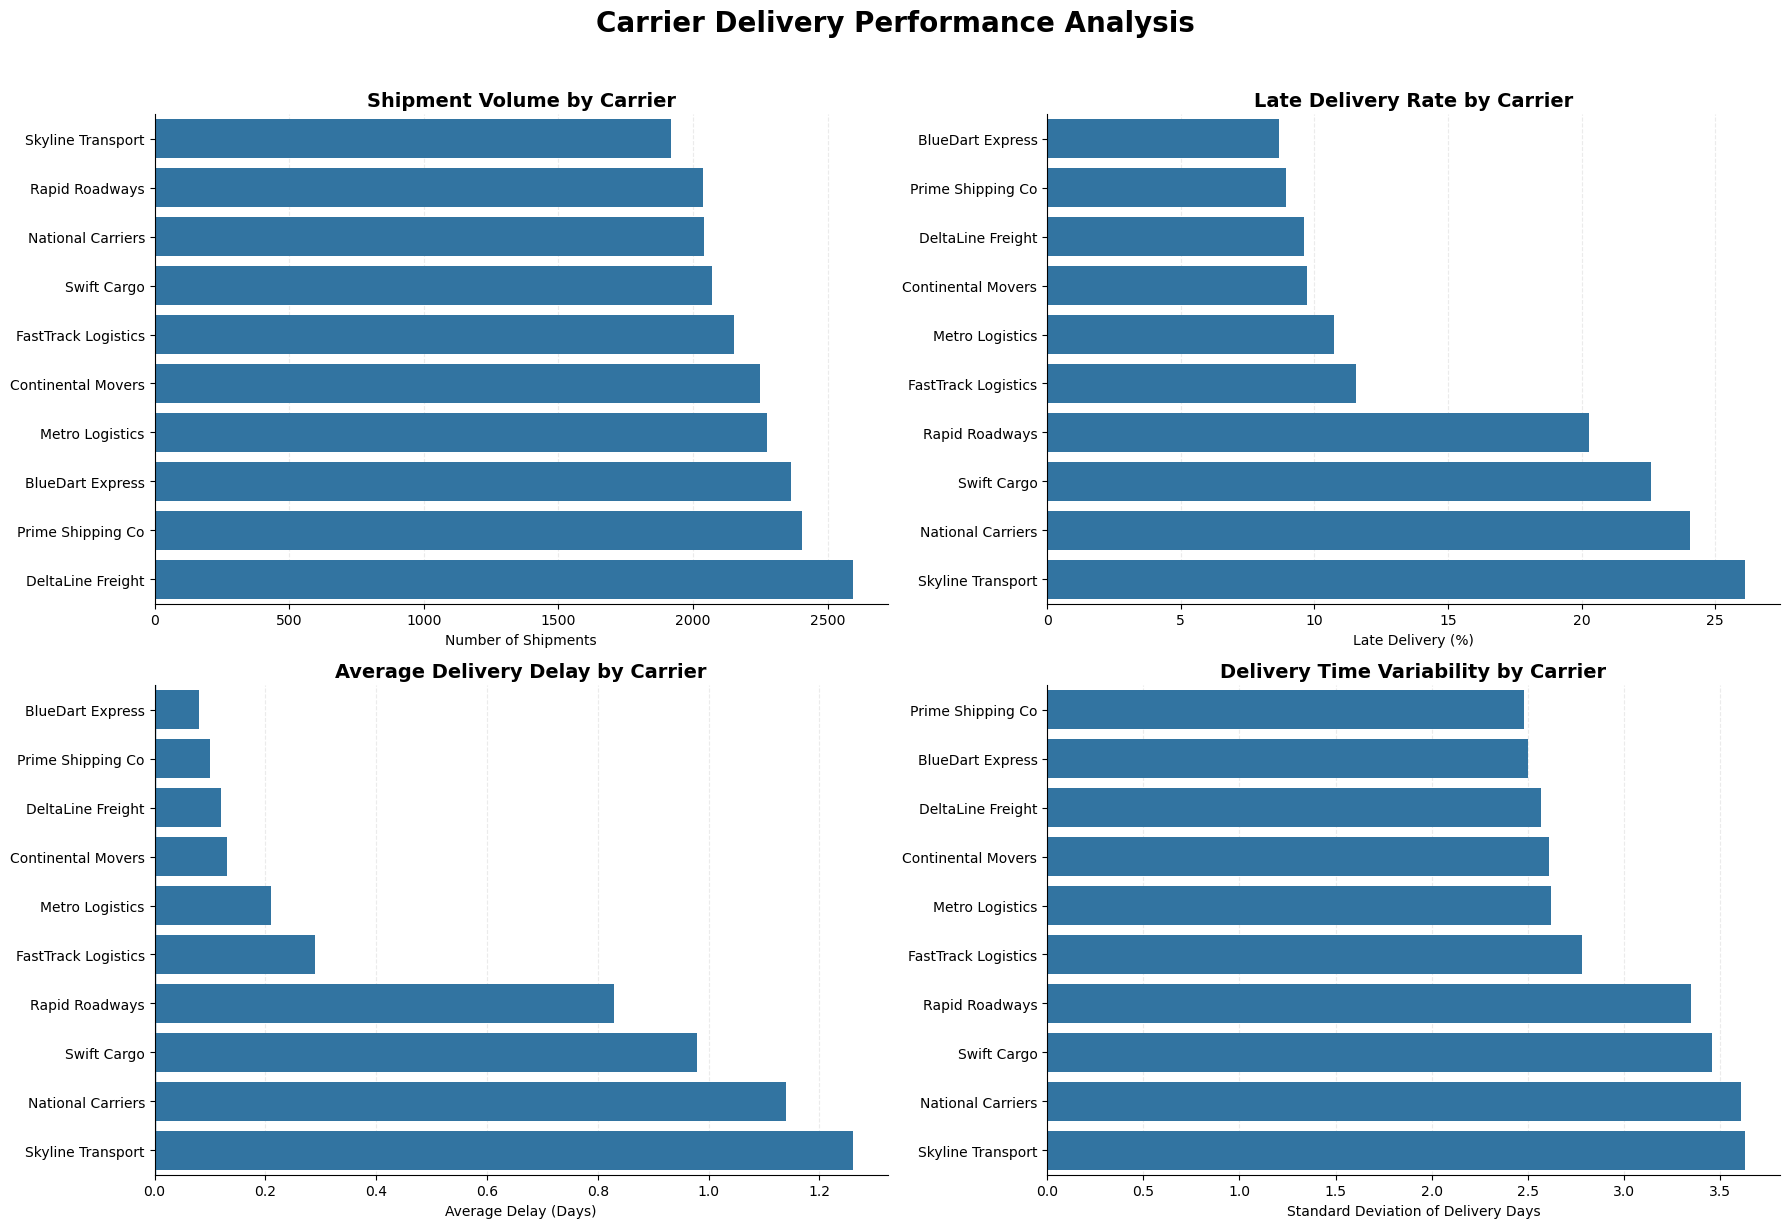

In [53]:
# ============================================================
# Q7: Carrier Delivery Performance — Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

fig.suptitle(
    "Carrier Delivery Performance Analysis",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Shipment Volume
# ------------------------------------------------------------

data = carrier_summary.sort_values(
    "Total_Shipments",
    ascending=True
)

sns.barplot(
    data=data,
    x="Total_Shipments",
    y="CarrierName",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Carrier",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Number of Shipments")
axes[0, 0].set_ylabel("")


# ------------------------------------------------------------
# 2. Late Delivery Rate
# ------------------------------------------------------------

data = carrier_summary.sort_values(
    "Late_Delivery_Rate",
    ascending=True
)

sns.barplot(
    data=data,
    x="Late_Delivery_Rate",
    y="CarrierName",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Carrier",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Late Delivery (%)")
axes[0, 1].set_ylabel("")


# ------------------------------------------------------------
# 3. Average Delivery Delay
# ------------------------------------------------------------

data = carrier_summary.sort_values(
    "Avg_Delay_Days",
    ascending=True
)

sns.barplot(
    data=data,
    x="Avg_Delay_Days",
    y="CarrierName",
    ax=axes[1, 0]
)

axes[1, 0].axvline(
    0,
    linewidth=1
)

axes[1, 0].set_title(
    "Average Delivery Delay by Carrier",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Average Delay (Days)")
axes[1, 0].set_ylabel("")


# ------------------------------------------------------------
# 4. Delivery Time Variability
# ------------------------------------------------------------

data = carrier_summary.sort_values(
    "Delivery_Days_Std",
    ascending=True
)

sns.barplot(
    data=data,
    x="Delivery_Days_Std",
    y="CarrierName",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Delivery Time Variability by Carrier",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Standard Deviation of Delivery Days"
)

axes[1, 1].set_ylabel("")


# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q8 — Does warehouse processing time contribute to delivery delays?

#### Does longer warehouse processing time lead to higher late-delivery rates and longer overall delivery times?

In [55]:
# Create processing-time bands using quartiles
Fact_Shipments["Warehouse_Processing_Band"] = pd.qcut(
    Fact_Shipments["WarehouseProcessingTimeHours"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Calculate delivery performance by processing-time band
warehouse_summary = (
    Fact_Shipments
    .groupby("Warehouse_Processing_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Processing_Hours=(
            "WarehouseProcessingTimeHours",
            "mean"
        ),
        Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late delivery rate into percentage
warehouse_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
warehouse_summary = warehouse_summary.round(2)

warehouse_summary

,Warehouse_Processing_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Processing_Hours,Avg_Delivery_Days,Avg_Delay_Days
0,Low,5457,642,11.76,1.49,4.13,0.28
1,Medium,5409,686,12.68,2.64,4.12,0.34
2,High,5415,804,14.85,3.49,4.29,0.48
3,Very High,5386,1058,19.64,4.96,4.68,0.83


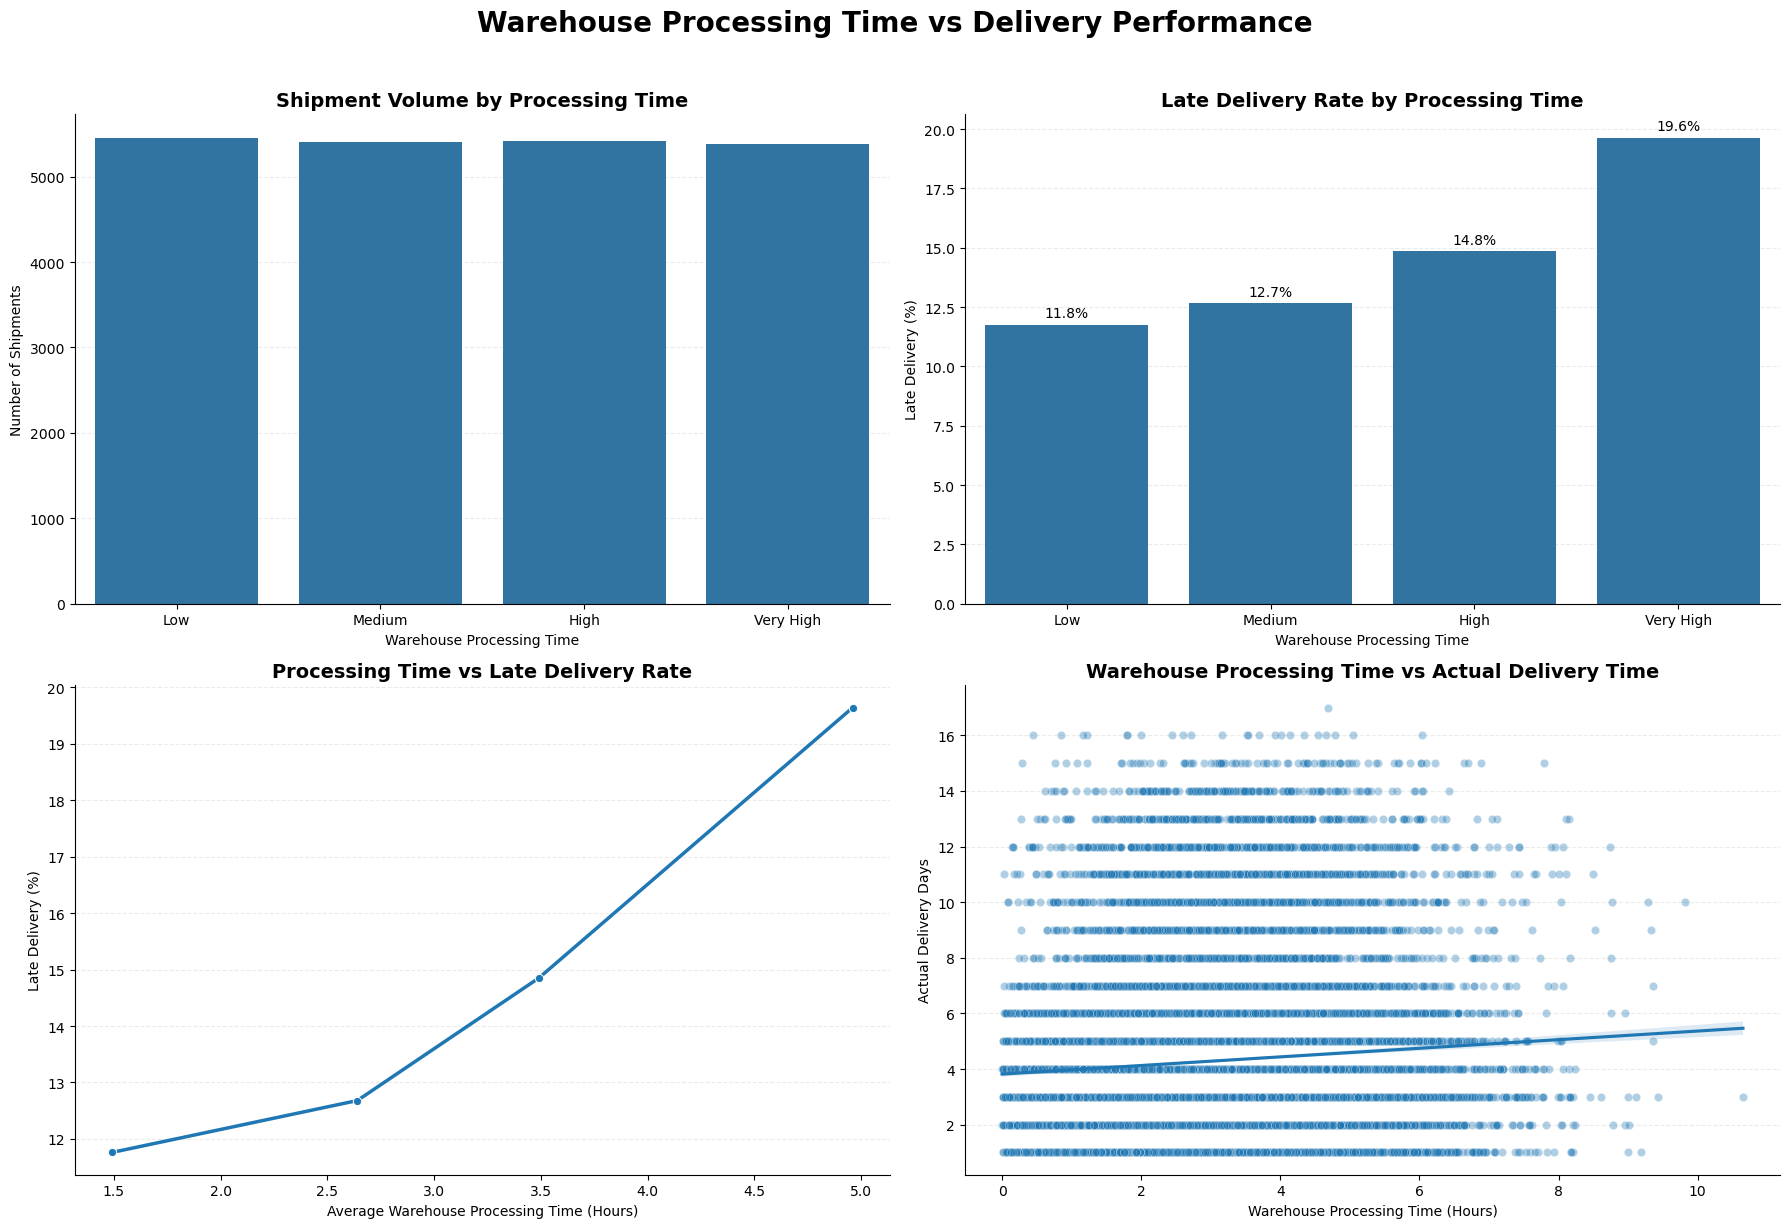

In [56]:
# ============================================================
# Q8: Warehouse Processing Time — Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

fig.suptitle(
    "Warehouse Processing Time vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Shipment Volume
# ------------------------------------------------------------

sns.barplot(
    data=warehouse_summary,
    x="Warehouse_Processing_Band",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Processing Time",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Warehouse Processing Time")
axes[0, 0].set_ylabel("Number of Shipments")


# ------------------------------------------------------------
# 2. Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=warehouse_summary,
    x="Warehouse_Processing_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Processing Time",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Warehouse Processing Time")
axes[0, 1].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 3. Processing Hours vs Late Delivery Rate
# ------------------------------------------------------------

sns.lineplot(
    data=warehouse_summary,
    x="Avg_Processing_Hours",
    y="Late_Delivery_Rate",
    marker="o",
    linewidth=2.5,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Processing Time vs Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Average Warehouse Processing Time (Hours)"
)

axes[1, 0].set_ylabel(
    "Late Delivery (%)"
)


# ------------------------------------------------------------
# 4. Processing Time vs Actual Delivery Days
# ------------------------------------------------------------

sns.scatterplot(
    data=Fact_Shipments,
    x="WarehouseProcessingTimeHours",
    y="ActualDeliveryDays",
    alpha=0.35,
    ax=axes[1, 1]
)

# Add trend line
sns.regplot(
    data=Fact_Shipments,
    x="WarehouseProcessingTimeHours",
    y="ActualDeliveryDays",
    scatter=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Warehouse Processing Time vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Warehouse Processing Time (Hours)"
)

axes[1, 1].set_ylabel(
    "Actual Delivery Days"
)


# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q9 — Do handling and loading times affect delivery performance?

#### Do shipments requiring more handling or loading time have higher late-delivery rates and longer actual delivery times?

In [58]:
# Create quartile-based handling time categories
Fact_Shipments["Handling_Time_Band"] = pd.qcut(
    Fact_Shipments["HandlingTimeHours"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Create quartile-based loading time categories
Fact_Shipments["Loading_Time_Band"] = pd.qcut(
    Fact_Shipments["LoadingTimeHours"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)


# ------------------------------------------------------------
# Handling time summary
# ------------------------------------------------------------

handling_summary = (
    Fact_Shipments
    .groupby("Handling_Time_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Handling_Hours=("HandlingTimeHours", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        )
    )
    .reset_index()
)

handling_summary["Late_Delivery_Rate"] *= 100


# ------------------------------------------------------------
# Loading time summary
# ------------------------------------------------------------

loading_summary = (
    Fact_Shipments
    .groupby("Loading_Time_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Loading_Hours=("LoadingTimeHours", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        )
    )
    .reset_index()
)

loading_summary["Late_Delivery_Rate"] *= 100


# Round numerical values
handling_summary = handling_summary.round(2)
loading_summary = loading_summary.round(2)


# Display both summaries
print("Handling Time Summary")
display(handling_summary)

print("\nLoading Time Summary")
display(loading_summary)

Handling Time Summary


,Handling_Time_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Handling_Hours,Avg_Actual_Days,Avg_Delay_Days
0,Low,5617,762,13.57,0.74,4.20,0.40
1,Medium,5508,720,13.07,1.31,4.17,0.37
2,High,5531,858,15.51,1.74,4.38,0.53
3,Very High,5454,914,16.76,2.48,4.46,0.63



Loading Time Summary


,Loading_Time_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Loading_Hours,Avg_Actual_Days,Avg_Delay_Days
0,Low,5599,772,13.79,0.50,4.25,0.41
1,Medium,5650,820,14.51,0.88,4.28,0.46
2,High,5462,791,14.48,1.17,4.29,0.47
3,Very High,5399,871,16.13,1.68,4.39,0.58


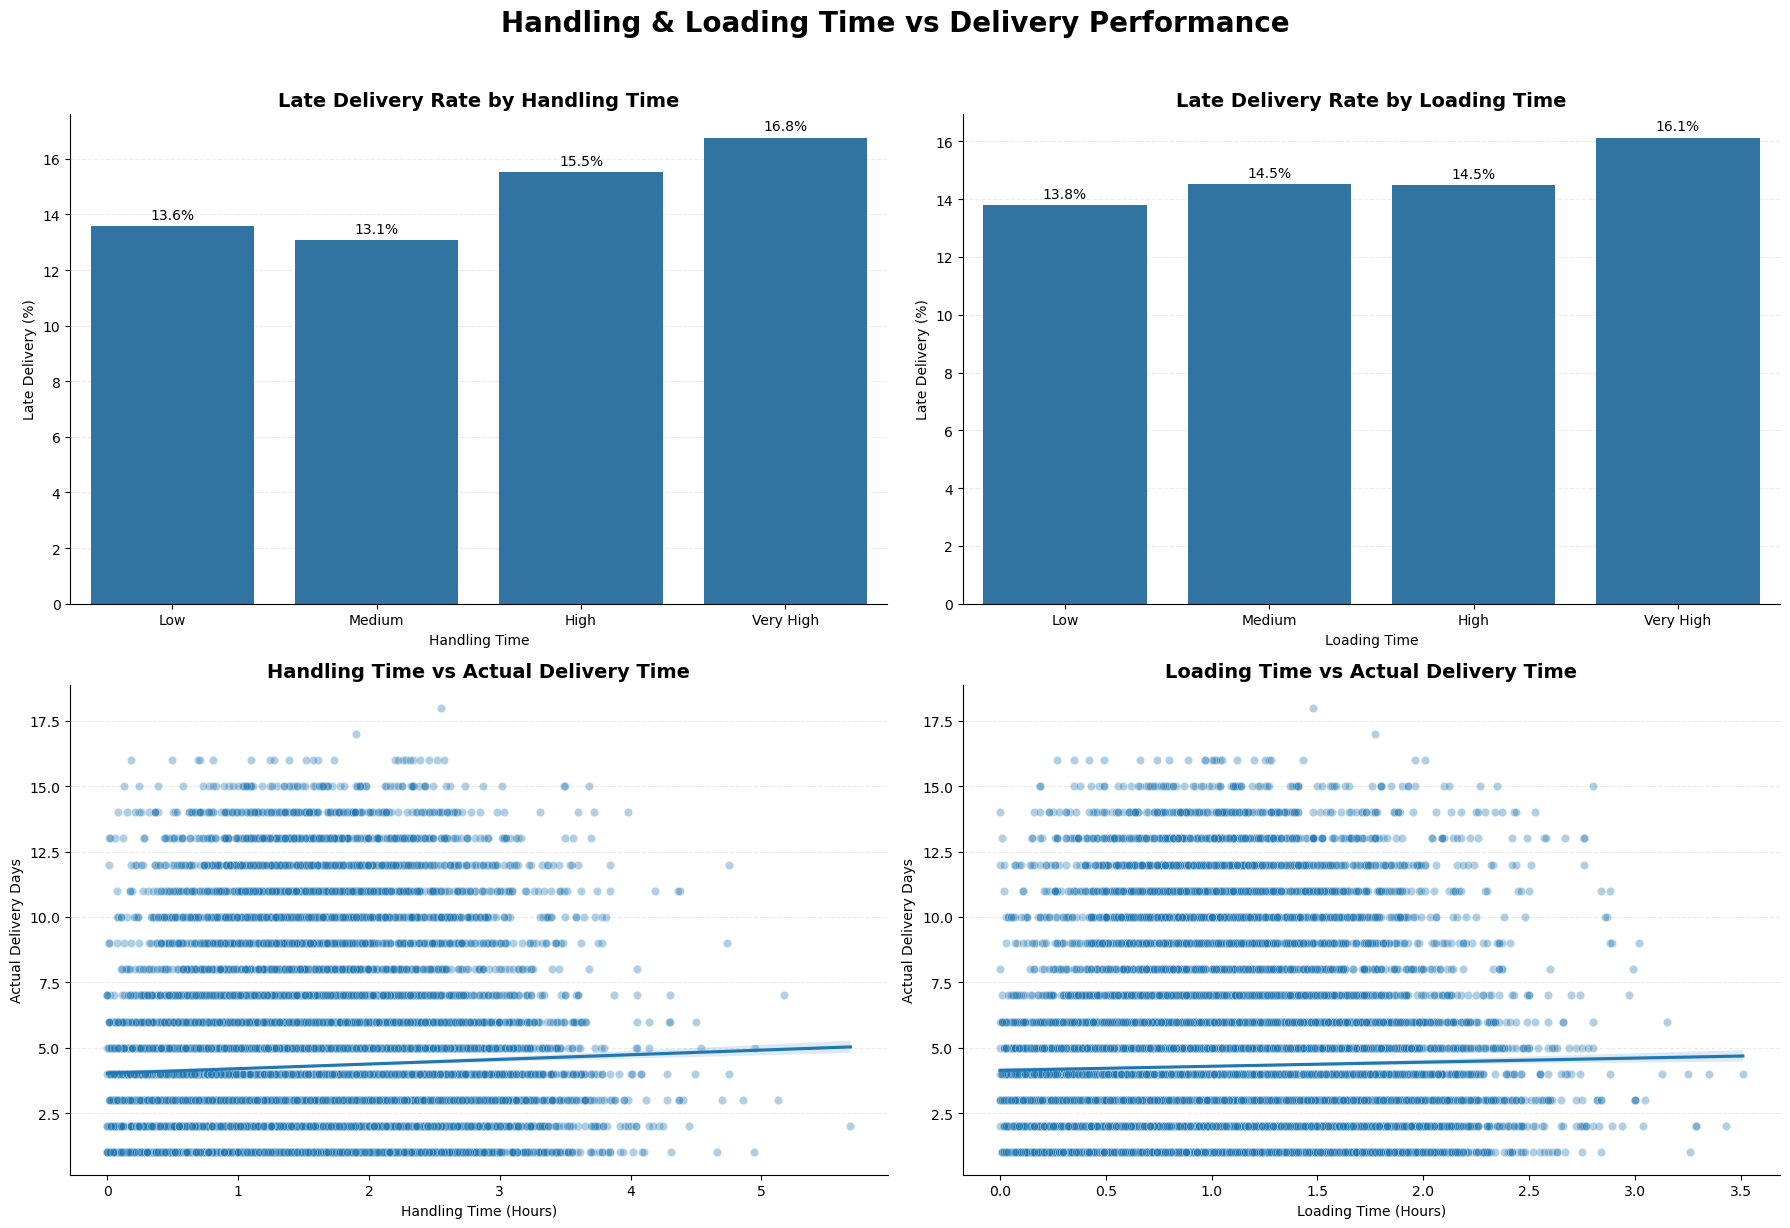

In [59]:
# ============================================================
# Q9: Handling & Loading Time — Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

fig.suptitle(
    "Handling & Loading Time vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Handling Time vs Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=handling_summary,
    x="Handling_Time_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Late Delivery Rate by Handling Time",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Handling Time")
axes[0, 0].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 2. Loading Time vs Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=loading_summary,
    x="Loading_Time_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Loading Time",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Loading Time")
axes[0, 1].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 3. Handling Time vs Actual Delivery Days
# ------------------------------------------------------------

sns.scatterplot(
    data=Fact_Shipments,
    x="HandlingTimeHours",
    y="ActualDeliveryDays",
    alpha=0.35,
    ax=axes[1, 0]
)

sns.regplot(
    data=Fact_Shipments,
    x="HandlingTimeHours",
    y="ActualDeliveryDays",
    scatter=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Handling Time vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Handling Time (Hours)"
)

axes[1, 0].set_ylabel(
    "Actual Delivery Days"
)


# ------------------------------------------------------------
# 4. Loading Time vs Actual Delivery Days
# ------------------------------------------------------------

sns.scatterplot(
    data=Fact_Shipments,
    x="LoadingTimeHours",
    y="ActualDeliveryDays",
    alpha=0.35,
    ax=axes[1, 1]
)

sns.regplot(
    data=Fact_Shipments,
    x="LoadingTimeHours",
    y="ActualDeliveryDays",
    scatter=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Loading Time vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Loading Time (Hours)"
)

axes[1, 1].set_ylabel(
    "Actual Delivery Days"
)


# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q10 — Does warehouse performance vary significantly across warehouses?

#### How consistently are shipments processed and delivered across different warehouses, and does higher warehouse activity correspond to different delivery performance?

In [65]:
# Calculate performance metrics for each warehouse
warehouse_performance = (
    Fact_Shipments
    .groupby("WarehouseID")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Processing_Hours=(
            "WarehouseProcessingTimeHours",
            "mean"
        ),
        Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        )
    )
    .reset_index())

# Convert late-delivery rate to percentage
warehouse_performance["Late_Delivery_Rate"] *= 100

# Round numerical values
warehouse_performance = warehouse_performance.round(2)

# Sort by late-delivery rate
warehouse_performance = (
    warehouse_performance
    .sort_values(
        "Late_Delivery_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

warehouse_performance

,WarehouseID,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Processing_Hours,Avg_Delivery_Days,Avg_Delay_Days
0,14,755,162,21.46,4.59,4.66,0.94
1,24,736,143,19.43,4.31,4.66,0.79
2,10,733,136,18.55,4.04,4.59,0.74
3,3,765,139,18.17,4.08,4.51,0.73
4,28,735,129,17.55,3.80,4.47,0.66
5,27,688,114,16.57,3.21,4.42,0.62
6,13,737,114,15.47,2.96,4.34,0.50
7,15,759,116,15.28,3.32,4.46,0.53
8,5,779,119,15.28,3.45,4.33,0.47
9,7,733,111,15.14,3.40,4.32,0.53


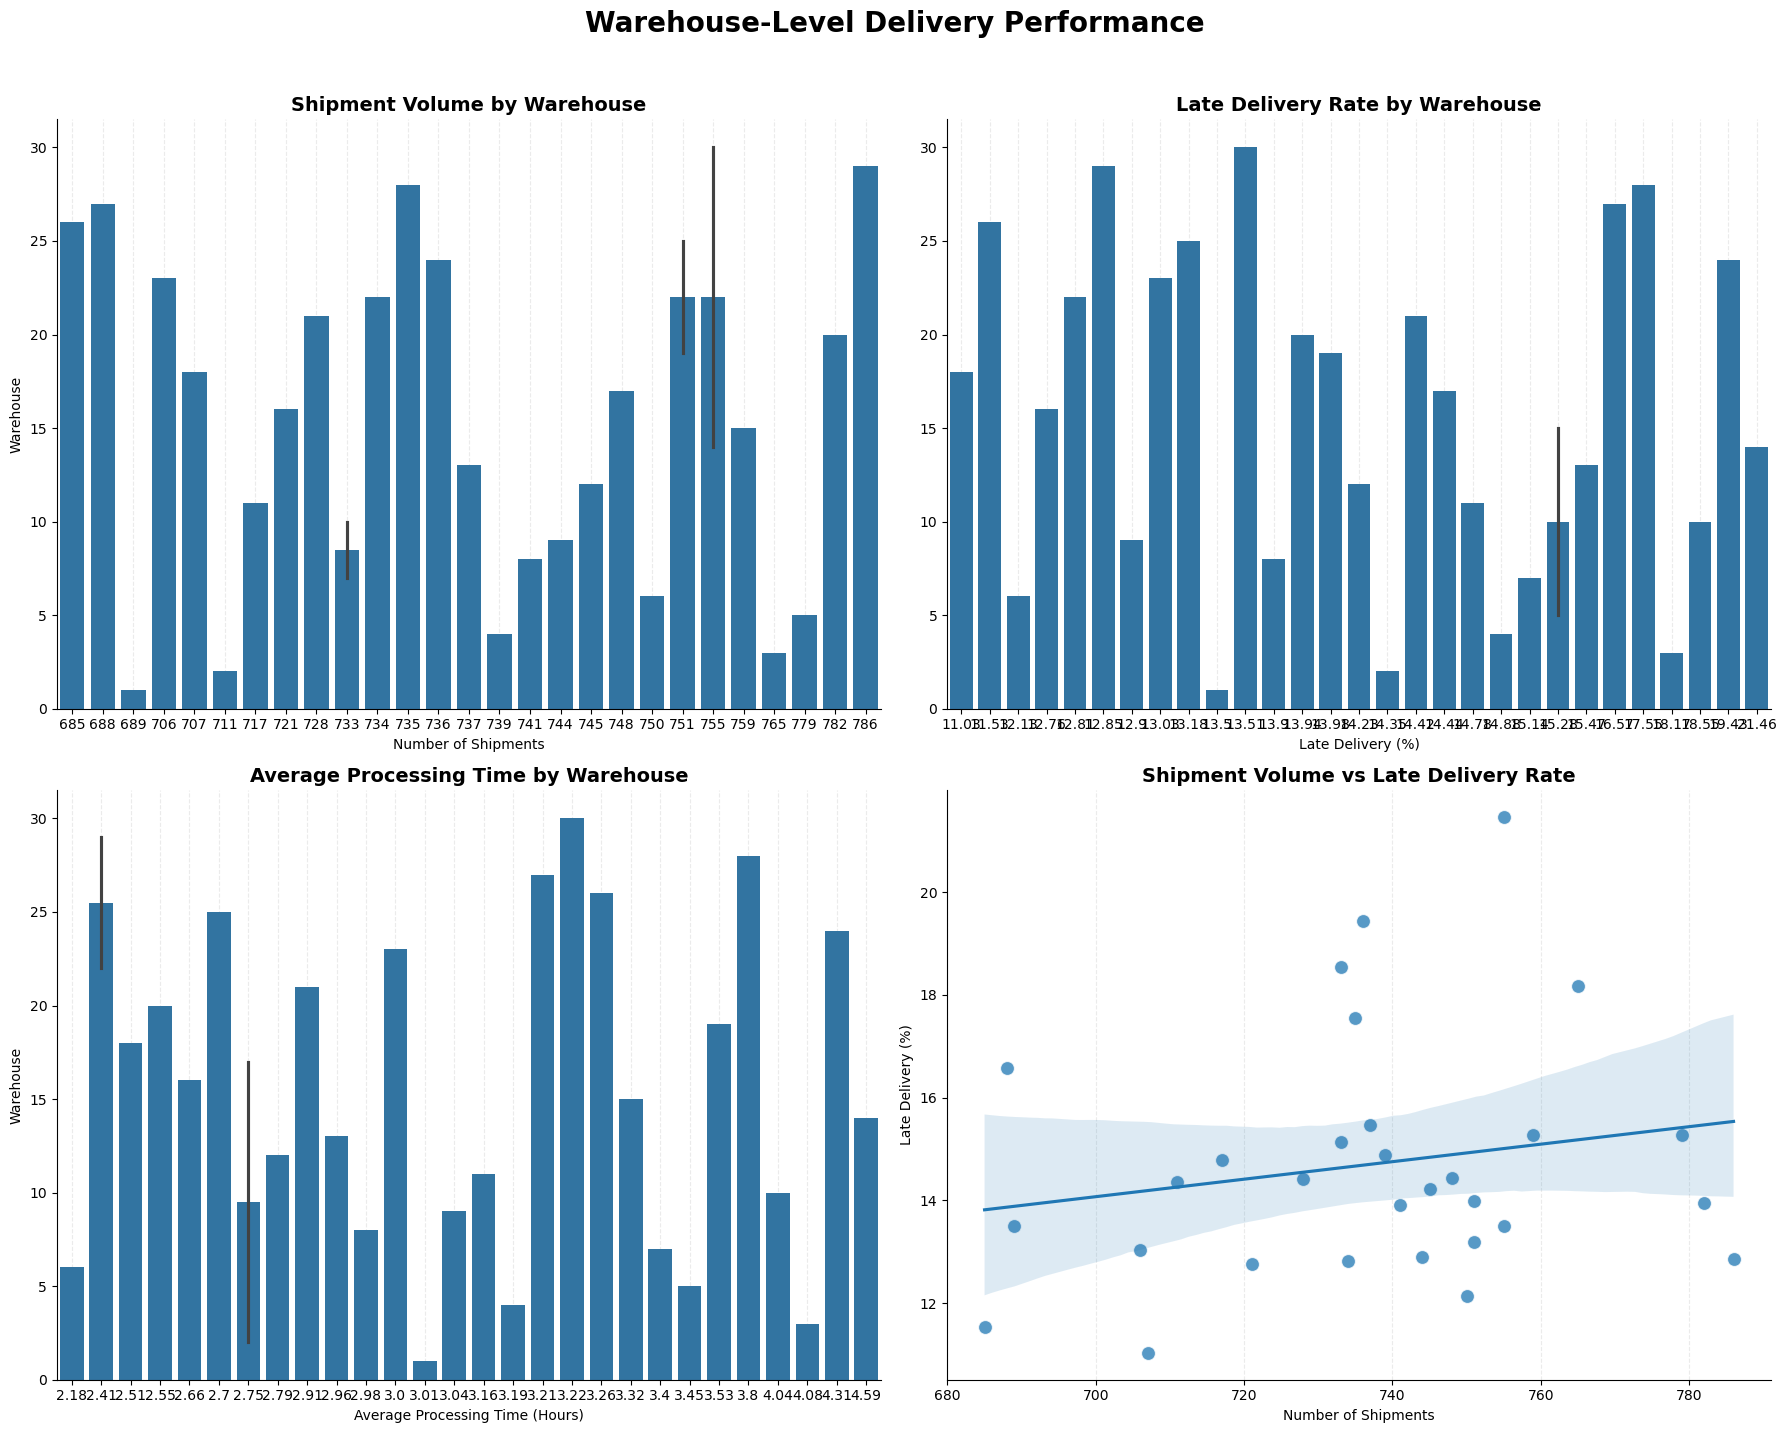

In [67]:
# ============================================================
# Q10: Warehouse Performance — Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 14)
)

fig.suptitle(
    "Warehouse-Level Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Shipment Volume by Warehouse
# ------------------------------------------------------------

data = warehouse_performance.sort_values(
    "Total_Shipments",
    ascending=True
)

sns.barplot(
    data=data,
    x="Total_Shipments",
    y="WarehouseID",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Warehouse",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Number of Shipments")
axes[0, 0].set_ylabel("Warehouse")


# ------------------------------------------------------------
# 2. Late Delivery Rate by Warehouse
# ------------------------------------------------------------

data = warehouse_performance.sort_values(
    "Late_Delivery_Rate",
    ascending=True
)

sns.barplot(
    data=data,
    x="Late_Delivery_Rate",
    y="WarehouseID",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Warehouse",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Late Delivery (%)")
axes[0, 1].set_ylabel("")


# ------------------------------------------------------------
# 3. Average Warehouse Processing Time
# ------------------------------------------------------------

data = warehouse_performance.sort_values(
    "Avg_Processing_Hours",
    ascending=True
)

sns.barplot(
    data=data,
    x="Avg_Processing_Hours",
    y="WarehouseID",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Average Processing Time by Warehouse",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Average Processing Time (Hours)"
)

axes[1, 0].set_ylabel("Warehouse")


# ------------------------------------------------------------
# 4. Shipment Volume vs Late Delivery Rate
# ------------------------------------------------------------

sns.scatterplot(
    data=warehouse_performance,
    x="Total_Shipments",
    y="Late_Delivery_Rate",
    s=100,
    alpha=0.75,
    ax=axes[1, 1]
)

# Add trend line
sns.regplot(
    data=warehouse_performance,
    x="Total_Shipments",
    y="Late_Delivery_Rate",
    scatter=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Shipment Volume vs Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Number of Shipments"
)

axes[1, 1].set_ylabel(
    "Late Delivery (%)"
)


# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q11 — Does vehicle age affect delivery performance?

#### Do older vehicles experience higher late-delivery rates or longer delivery times compared with newer vehicles?

In [68]:
# Merge vehicle information with shipment data
vehicle_data = Fact_Shipments.merge(
    Dim_Vehicles,
    on="VehicleID",
    how="left"
)

# Create vehicle age bands
vehicle_data["Vehicle_Age_Band"] = pd.cut(
    vehicle_data["VehicleAgeYears"],
    bins=[0, 3, 7, np.inf],
    labels=[
        "0–3 Years",
        "4–7 Years",
        "8+ Years"
    ],
    include_lowest=True
)

# Calculate delivery performance by vehicle age
vehicle_age_summary = (
    vehicle_data
    .groupby("Vehicle_Age_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=(
            "ActualDeliveryDays",
            lambda x: (
                x - vehicle_data.loc[
                    x.index,
                    "PromisedDeliveryDays"
                ]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late-delivery rate into percentage
vehicle_age_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
vehicle_age_summary = vehicle_age_summary.round(2)

vehicle_age_summary

,Vehicle_Age_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Delivery_Days,Avg_Delay_Days
0,0–3 Years,5659,559,9.88,3.97,0.15
1,4–7 Years,6482,778,12.00,4.09,0.29
2,8+ Years,9969,1917,19.23,4.63,0.79


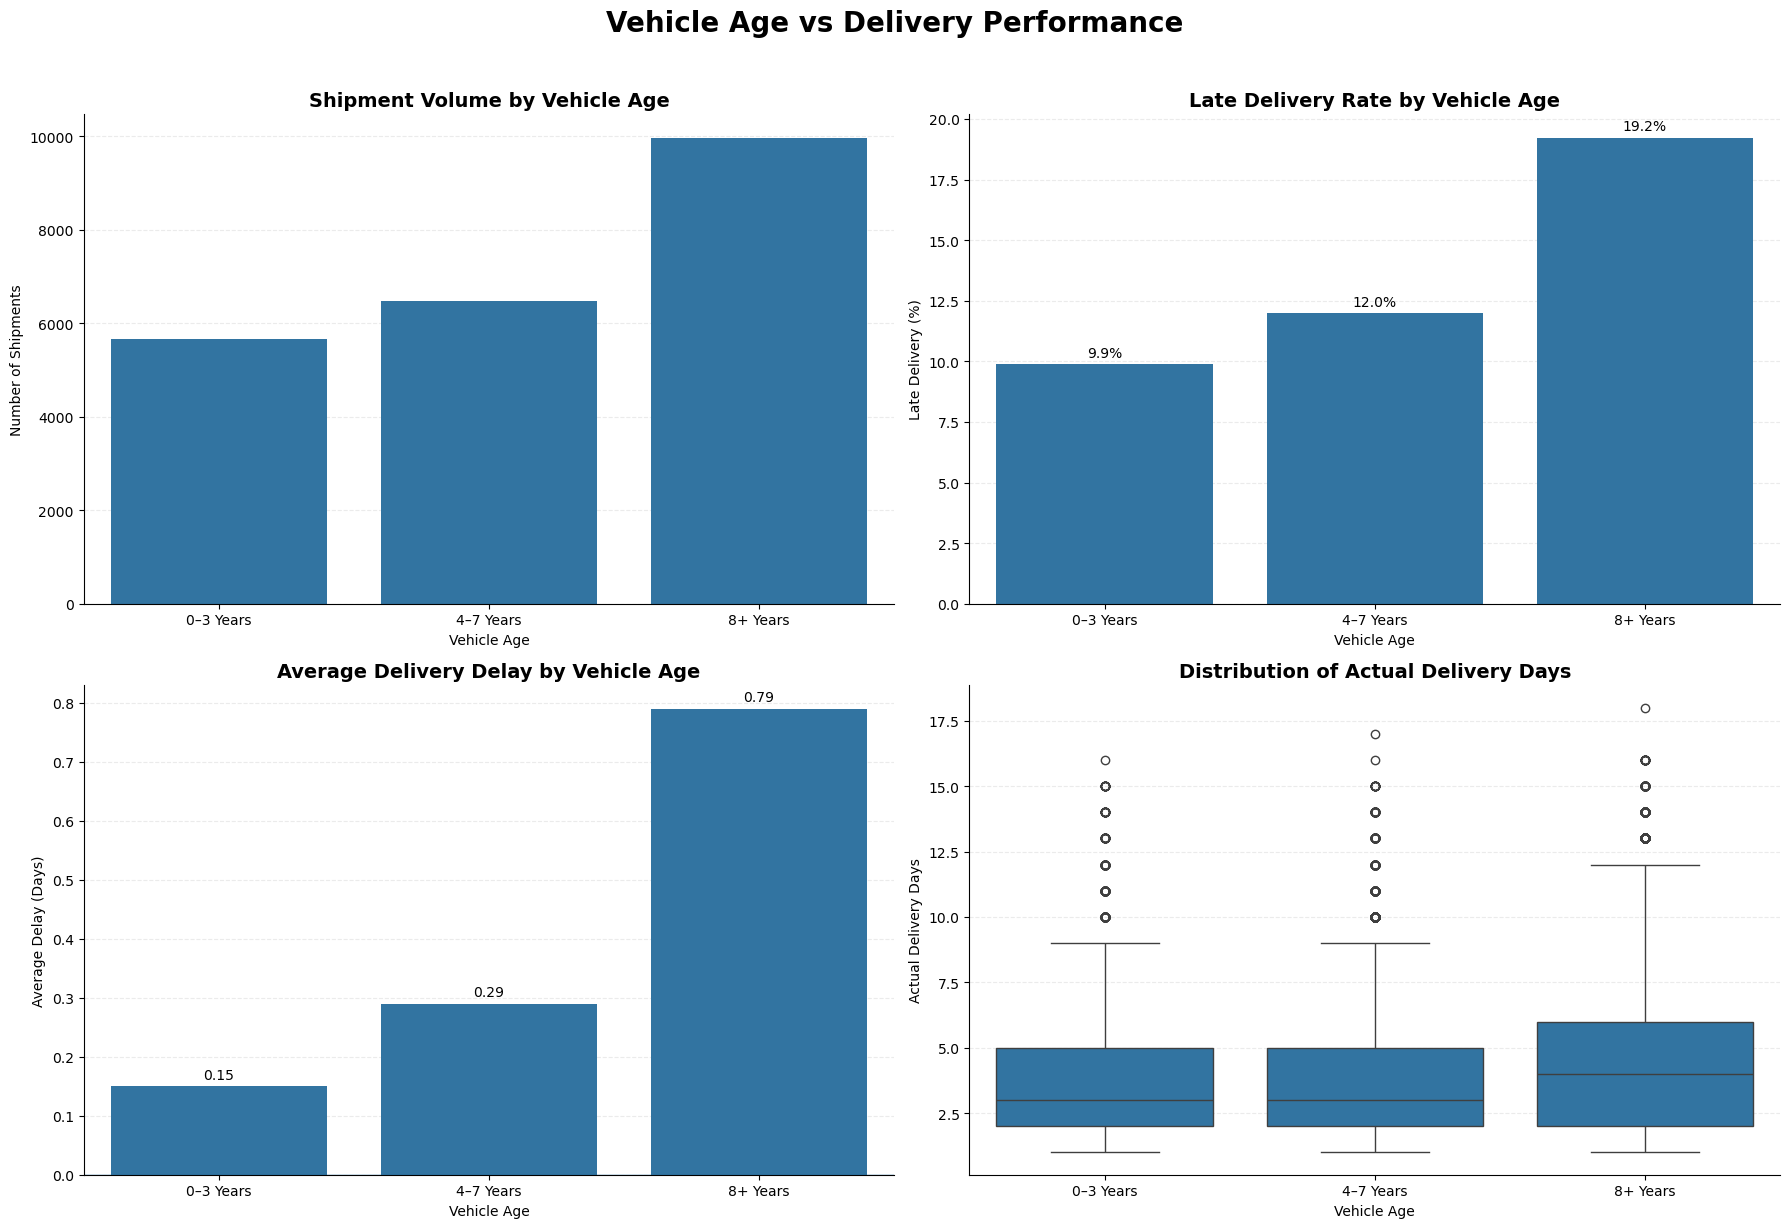

In [69]:
# ============================================================
# Q11: Vehicle Age — Visualization
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

fig.suptitle(
    "Vehicle Age vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


# ------------------------------------------------------------
# 1. Shipment Volume
# ------------------------------------------------------------

sns.barplot(
    data=vehicle_age_summary,
    x="Vehicle_Age_Band",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Vehicle Age",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Vehicle Age")
axes[0, 0].set_ylabel("Number of Shipments")


# ------------------------------------------------------------
# 2. Late Delivery Rate
# ------------------------------------------------------------

ax = sns.barplot(
    data=vehicle_age_summary,
    x="Vehicle_Age_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Vehicle Age",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Vehicle Age")
axes[0, 1].set_ylabel("Late Delivery (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 3. Average Delivery Delay
# ------------------------------------------------------------

ax = sns.barplot(
    data=vehicle_age_summary,
    x="Vehicle_Age_Band",
    y="Avg_Delay_Days",
    ax=axes[1, 0]
)

axes[1, 0].axhline(
    0,
    linewidth=1
)

axes[1, 0].set_title(
    "Average Delivery Delay by Vehicle Age",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Vehicle Age")
axes[1, 0].set_ylabel("Average Delay (Days)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )


# ------------------------------------------------------------
# 4. Actual Delivery Time Distribution
# ------------------------------------------------------------

sns.boxplot(
    data=vehicle_data,
    x="Vehicle_Age_Band",
    y="ActualDeliveryDays",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Distribution of Actual Delivery Days",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Vehicle Age")
axes[1, 1].set_ylabel("Actual Delivery Days")


# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------

for ax in axes.flat:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

######
# Q12 — Order Quantity vs Delivery Performance

#### Does shipment order quantity affect delivery performance, and do larger-volume shipments have higher late-delivery rates or longer delivery times?

In [70]:
# Create quantity bands using quartiles
Fact_Shipments["Order_Quantity_Band"] = pd.qcut(
    Fact_Shipments["OrderQuantity"],
    q=4,
    labels=["Low Quantity", "Medium Quantity", "High Quantity", "Very High Quantity"]
)

# Create summary table
quantity_summary = (
    Fact_Shipments
    .groupby("Order_Quantity_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Order_Quantity=("OrderQuantity", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
quantity_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
quantity_summary = quantity_summary.round(2)

quantity_summary

,Order_Quantity_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Order_Quantity,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days
0,Low Quantity,5564,795,14.29,3.53,3.83,4.29,0.46
1,Medium Quantity,6432,950,14.77,10.03,3.84,4.33,0.49
2,High Quantity,4614,694,15.04,16.00,3.80,4.31,0.51
3,Very High Quantity,5500,815,14.82,21.45,3.81,4.27,0.46


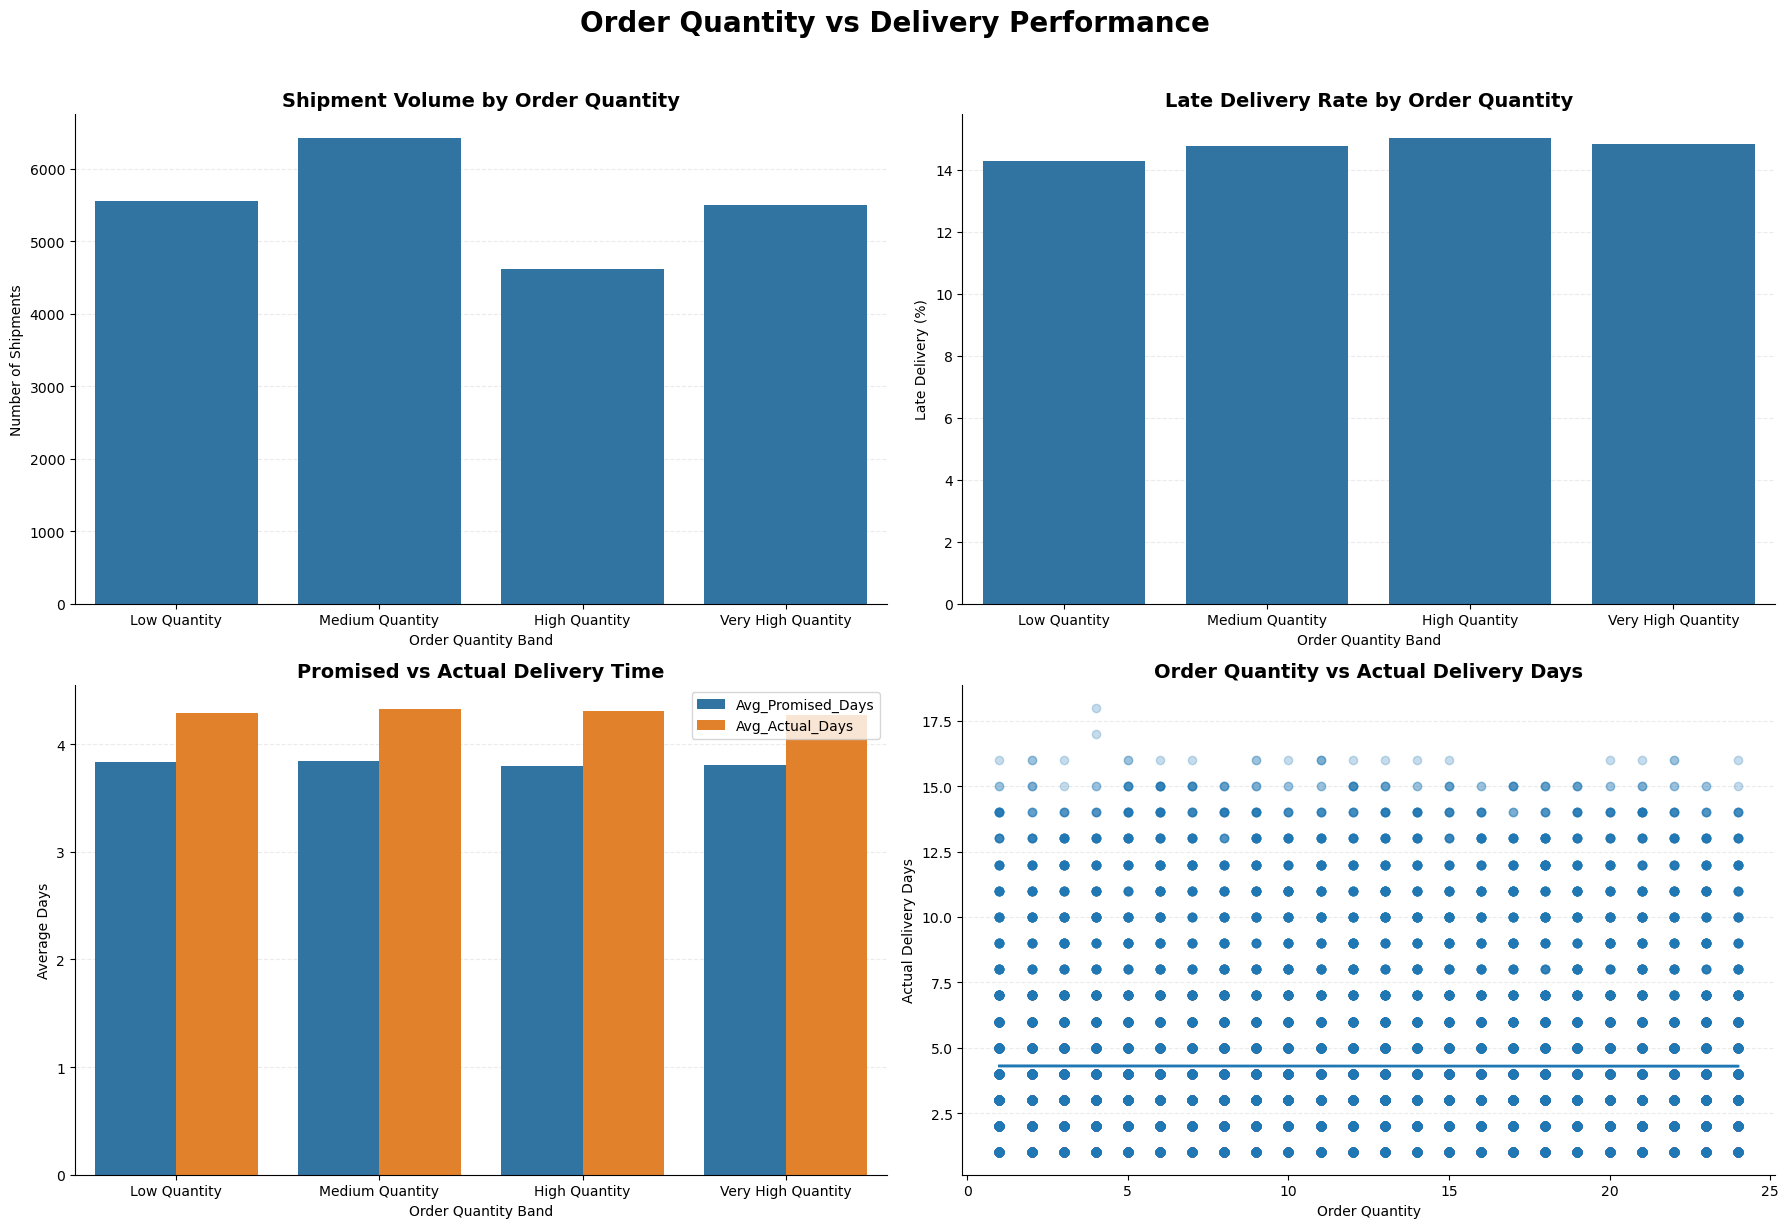

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Order Quantity vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Shipment volume by quantity band
sns.barplot(
    data=quantity_summary,
    x="Order_Quantity_Band",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Order Quantity",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Order Quantity Band")
axes[0, 0].set_ylabel("Number of Shipments")


# 2. Late delivery rate
sns.barplot(
    data=quantity_summary,
    x="Order_Quantity_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Order Quantity",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Order Quantity Band")
axes[0, 1].set_ylabel("Late Delivery (%)")


# 3. Promised vs actual delivery days
plot_data = quantity_summary.melt(
    id_vars="Order_Quantity_Band",
    value_vars=["Avg_Promised_Days", "Avg_Actual_Days"],
    var_name="Delivery_Type",
    value_name="Days"
)

sns.barplot(
    data=plot_data,
    x="Order_Quantity_Band",
    y="Days",
    hue="Delivery_Type",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Promised vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Order Quantity Band")
axes[1, 0].set_ylabel("Average Days")
axes[1, 0].legend(title="")


# 4. Order quantity vs actual delivery days
sns.regplot(
    data=Fact_Shipments,
    x="OrderQuantity",
    y="ActualDeliveryDays",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2},
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Order Quantity vs Actual Delivery Days",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Order Quantity")
axes[1, 1].set_ylabel("Actual Delivery Days")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q13 — Shipping Cost vs Delivery Performance

#### Does higher shipping cost correspond to longer delivery times or higher late-delivery rates, and are expensive shipments necessarily more difficult to deliver on time?

In [72]:
# Create shipping cost bands using quartiles
Fact_Shipments["Shipping_Cost_Band"] = pd.qcut(
    Fact_Shipments["ShippingCost"],
    q=4,
    labels=["Low Cost", "Medium Cost", "High Cost", "Very High Cost"]
)

# Create summary table
shipping_cost_summary = (
    Fact_Shipments
    .groupby("Shipping_Cost_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Shipping_Cost=("ShippingCost", "mean"),
        Avg_Distance_Km=("DistanceKm", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
shipping_cost_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
shipping_cost_summary = shipping_cost_summary.round(2)

shipping_cost_summary

,Shipping_Cost_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Shipping_Cost,Avg_Distance_Km,Avg_Actual_Days,Avg_Delay_Days
0,Low Cost,5445,296,5.44,872.10,574.34,2.47,-0.17
1,Medium Cost,5445,580,10.65,1522.89,1101.46,3.81,0.20
2,High Cost,5445,996,18.29,2107.51,1555.46,5.12,0.72
3,Very High Cost,5445,1331,24.44,3350.00,1858.31,5.81,1.16


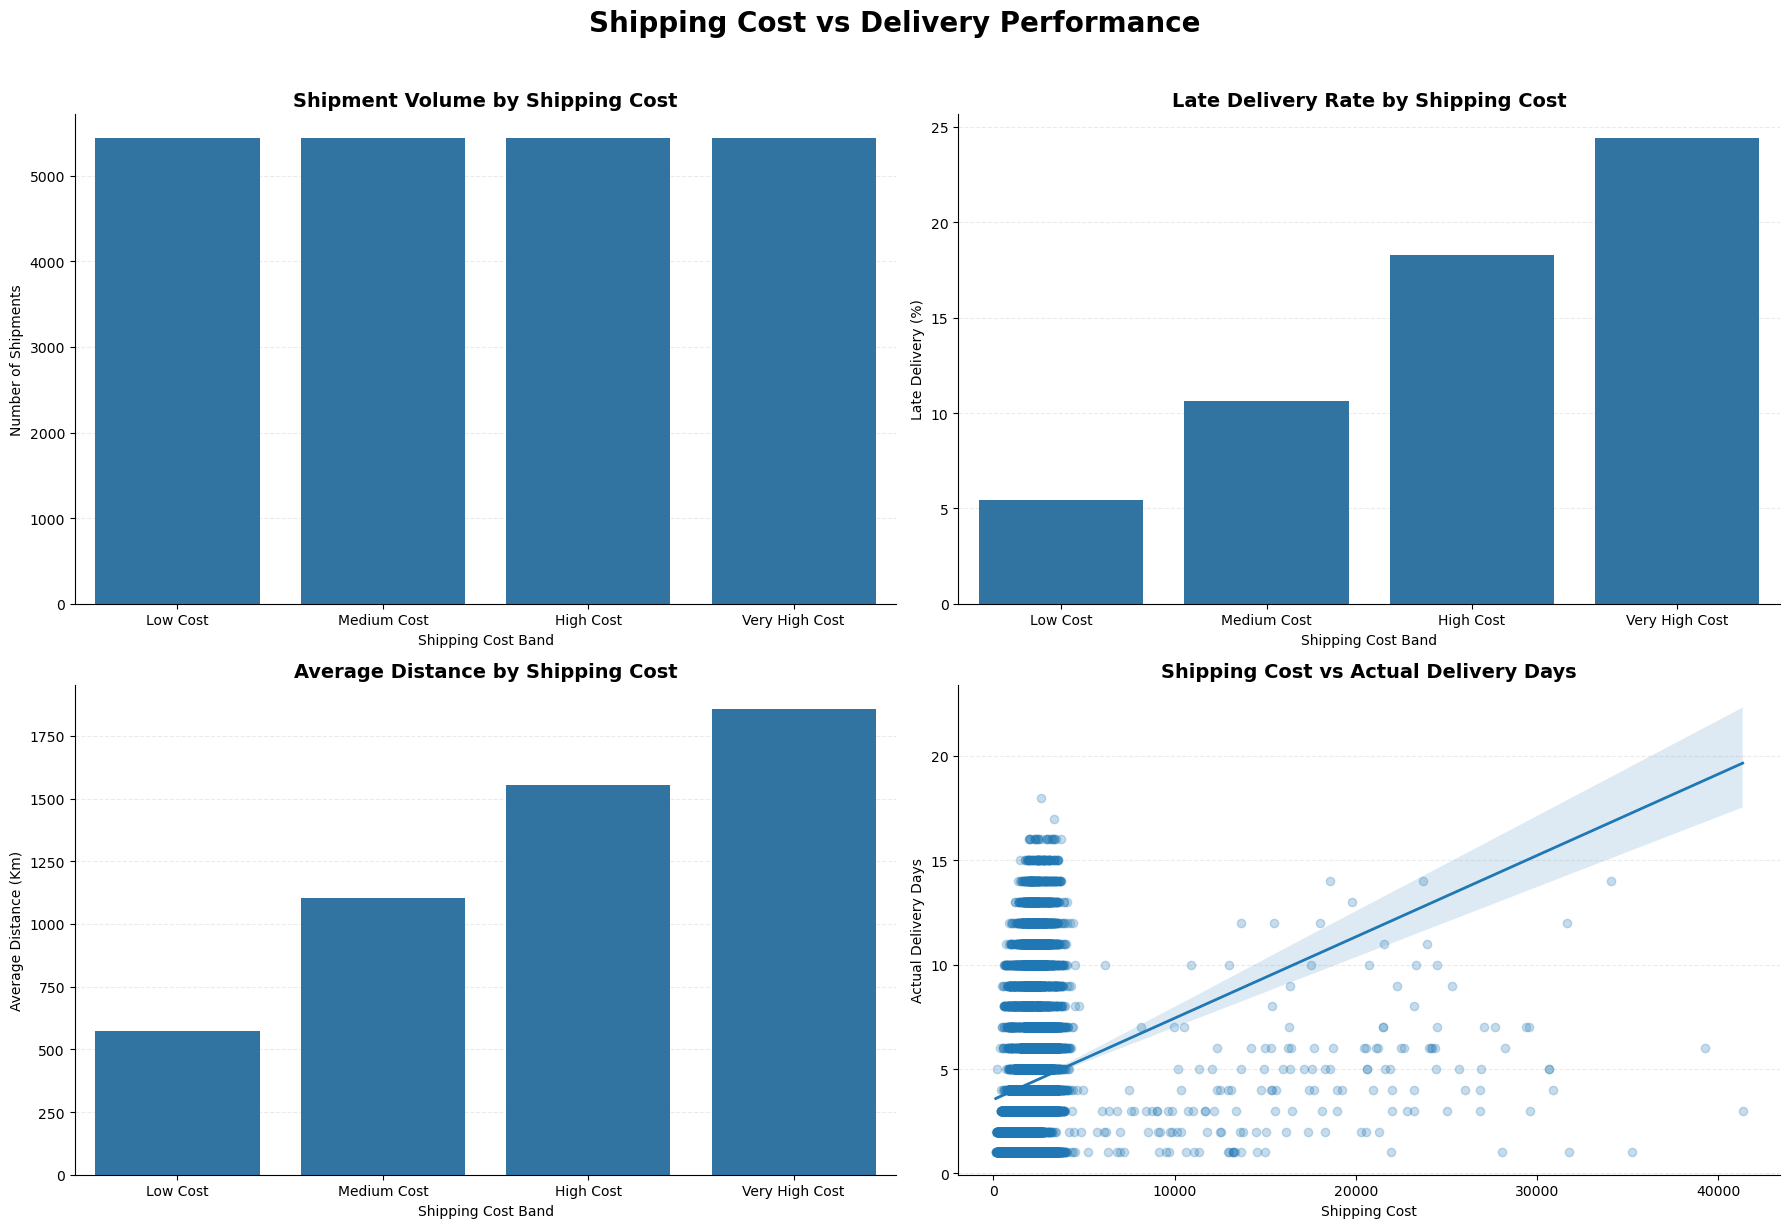

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Shipping Cost vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Shipment volume by shipping cost band
sns.barplot(
    data=shipping_cost_summary,
    x="Shipping_Cost_Band",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Shipping Cost",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Shipping Cost Band")
axes[0, 0].set_ylabel("Number of Shipments")


# 2. Late delivery rate by cost band
sns.barplot(
    data=shipping_cost_summary,
    x="Shipping_Cost_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Shipping Cost",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Shipping Cost Band")
axes[0, 1].set_ylabel("Late Delivery (%)")


# 3. Average distance vs shipping cost
sns.barplot(
    data=shipping_cost_summary,
    x="Shipping_Cost_Band",
    y="Avg_Distance_Km",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Average Distance by Shipping Cost",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Shipping Cost Band")
axes[1, 0].set_ylabel("Average Distance (Km)")


# 4. Shipping cost vs actual delivery days
sns.regplot(
    data=Fact_Shipments,
    x="ShippingCost",
    y="ActualDeliveryDays",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2},
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Shipping Cost vs Actual Delivery Days",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Shipping Cost")
axes[1, 1].set_ylabel("Actual Delivery Days")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q14 — Order Value vs Delivery Performance

#### Does the value of a shipment influence delivery performance, and are high-value shipments handled or delivered differently from lower-value shipments?

In [74]:
# Create order value bands using quartiles
Fact_Shipments["Order_Value_Band"] = pd.qcut(
    Fact_Shipments["OrderValue"],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "Very High Value"]
)

# Create summary table
order_value_summary = (
    Fact_Shipments
    .groupby("Order_Value_Band", observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Order_Value=("OrderValue", "mean"),
        Avg_Order_Quantity=("OrderQuantity", "mean"),
        Avg_Shipping_Cost=("ShippingCost", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
order_value_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
order_value_summary = order_value_summary.round(2)

order_value_summary

,Order_Value_Band,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Order_Value,Avg_Order_Quantity,Avg_Shipping_Cost,Avg_Actual_Days,Avg_Delay_Days
0,Low Value,5528,834,15.09,1833.25,10.62,1920.04,4.35,0.51
1,Medium Value,5527,804,14.55,3708.05,12.02,1930.22,4.25,0.46
2,High Value,5527,780,14.11,5227.54,12.71,1957.58,4.27,0.44
3,Very High Value,5528,836,15.12,7640.25,14.56,2044.40,4.34,0.52


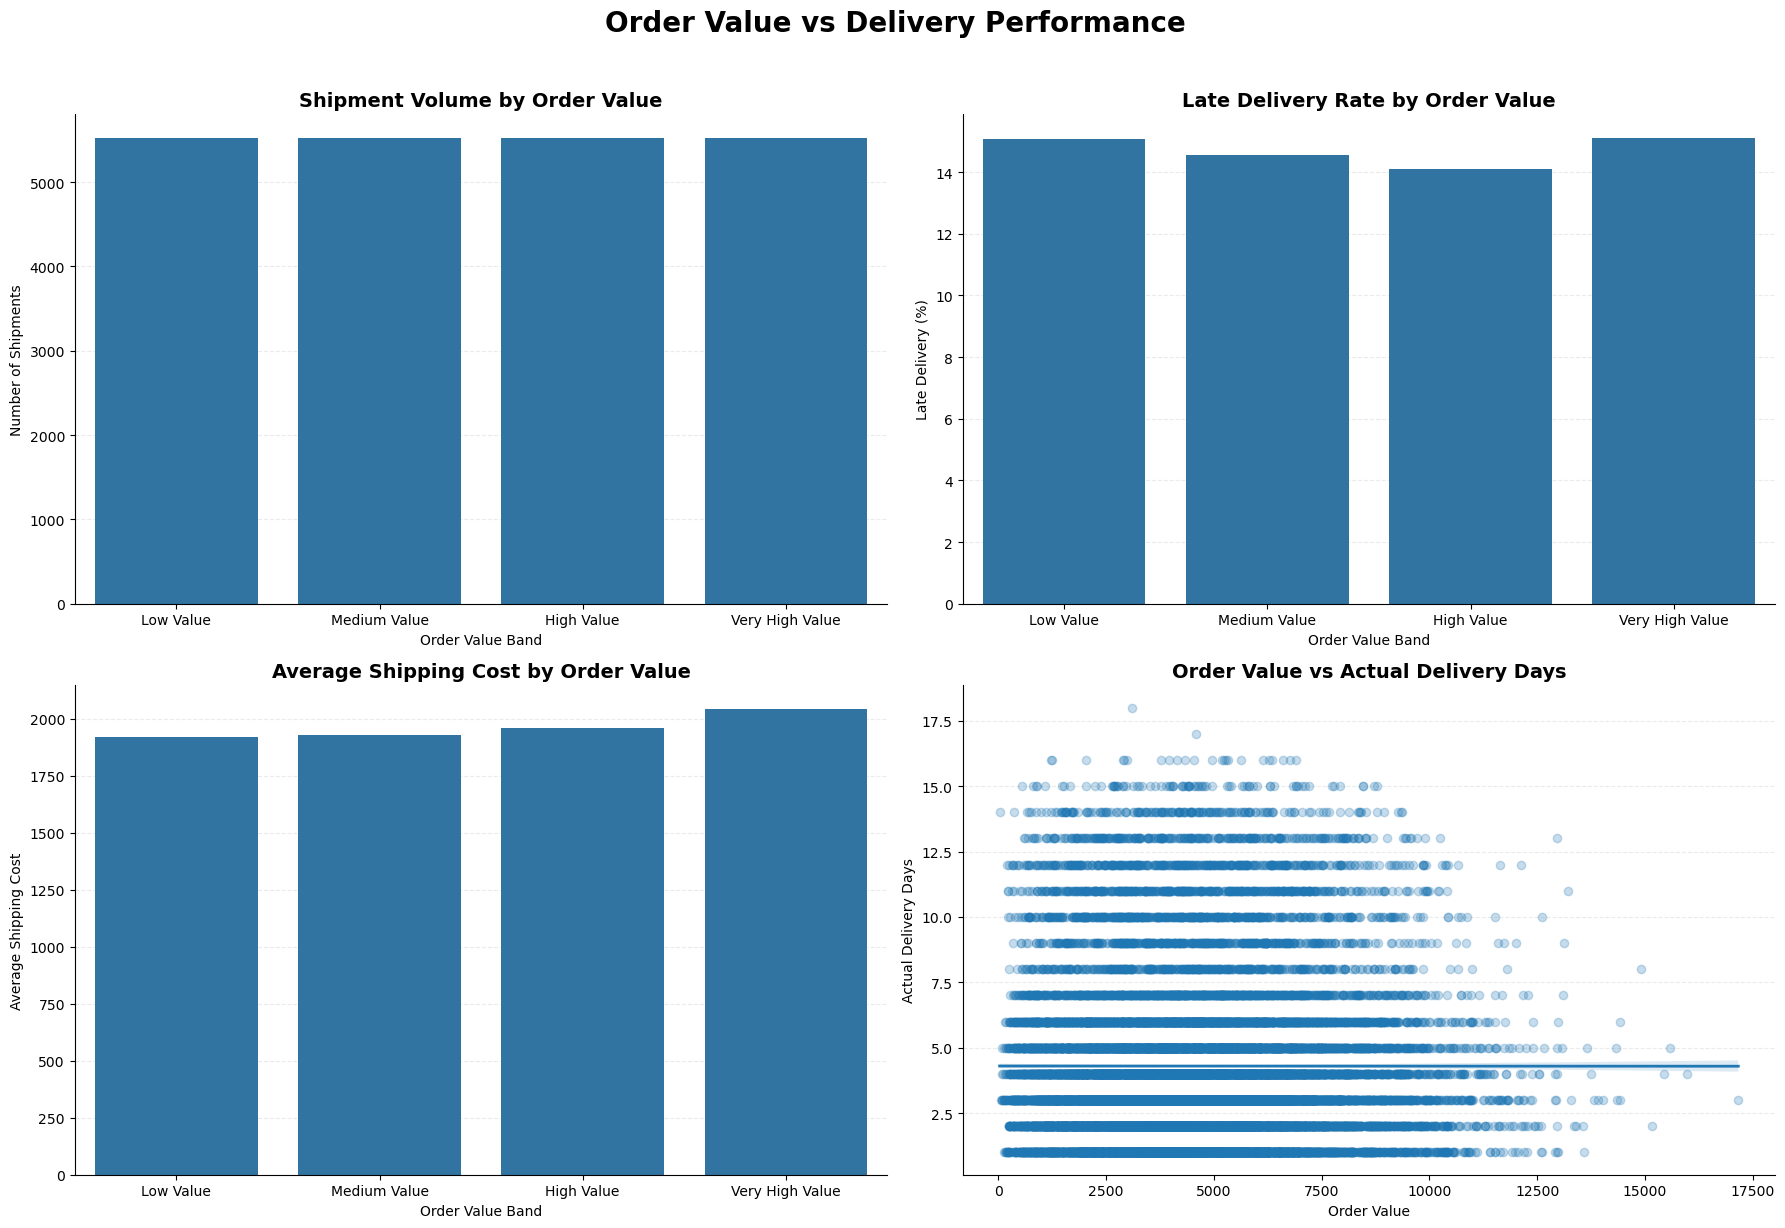

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Order Value vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Shipment volume by order value
sns.barplot(
    data=order_value_summary,
    x="Order_Value_Band",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Order Value",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Order Value Band")
axes[0, 0].set_ylabel("Number of Shipments")


# 2. Late delivery rate
sns.barplot(
    data=order_value_summary,
    x="Order_Value_Band",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Order Value",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Order Value Band")
axes[0, 1].set_ylabel("Late Delivery (%)")


# 3. Average shipping cost
sns.barplot(
    data=order_value_summary,
    x="Order_Value_Band",
    y="Avg_Shipping_Cost",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Average Shipping Cost by Order Value",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Order Value Band")
axes[1, 0].set_ylabel("Average Shipping Cost")


# 4. Order value vs actual delivery days
sns.regplot(
    data=Fact_Shipments,
    x="OrderValue",
    y="ActualDeliveryDays",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2},
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Order Value vs Actual Delivery Days",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Order Value")
axes[1, 1].set_ylabel("Actual Delivery Days")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q15 — Payment Method vs Delivery Performance

#### Does the payment method used for a shipment have any relationship with delivery performance, delivery time, or shipping cost?

In [76]:
# Create summary table by payment method
payment_summary = (
    Fact_Shipments
    .groupby("PaymentMethod")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Order_Value=("OrderValue", "mean"),
        Avg_Shipping_Cost=("ShippingCost", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
payment_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
payment_summary = payment_summary.round(2)

payment_summary

,PaymentMethod,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Order_Value,Avg_Shipping_Cost,Avg_Actual_Days,Avg_Delay_Days
0,COD,7612,1106,14.53,4637.60,1963.39,4.27,0.47
1,Credit Terms,4415,683,15.47,4594.95,1971.56,4.33,0.52
2,Prepaid,10083,1465,14.53,4578.83,1959.23,4.31,0.47


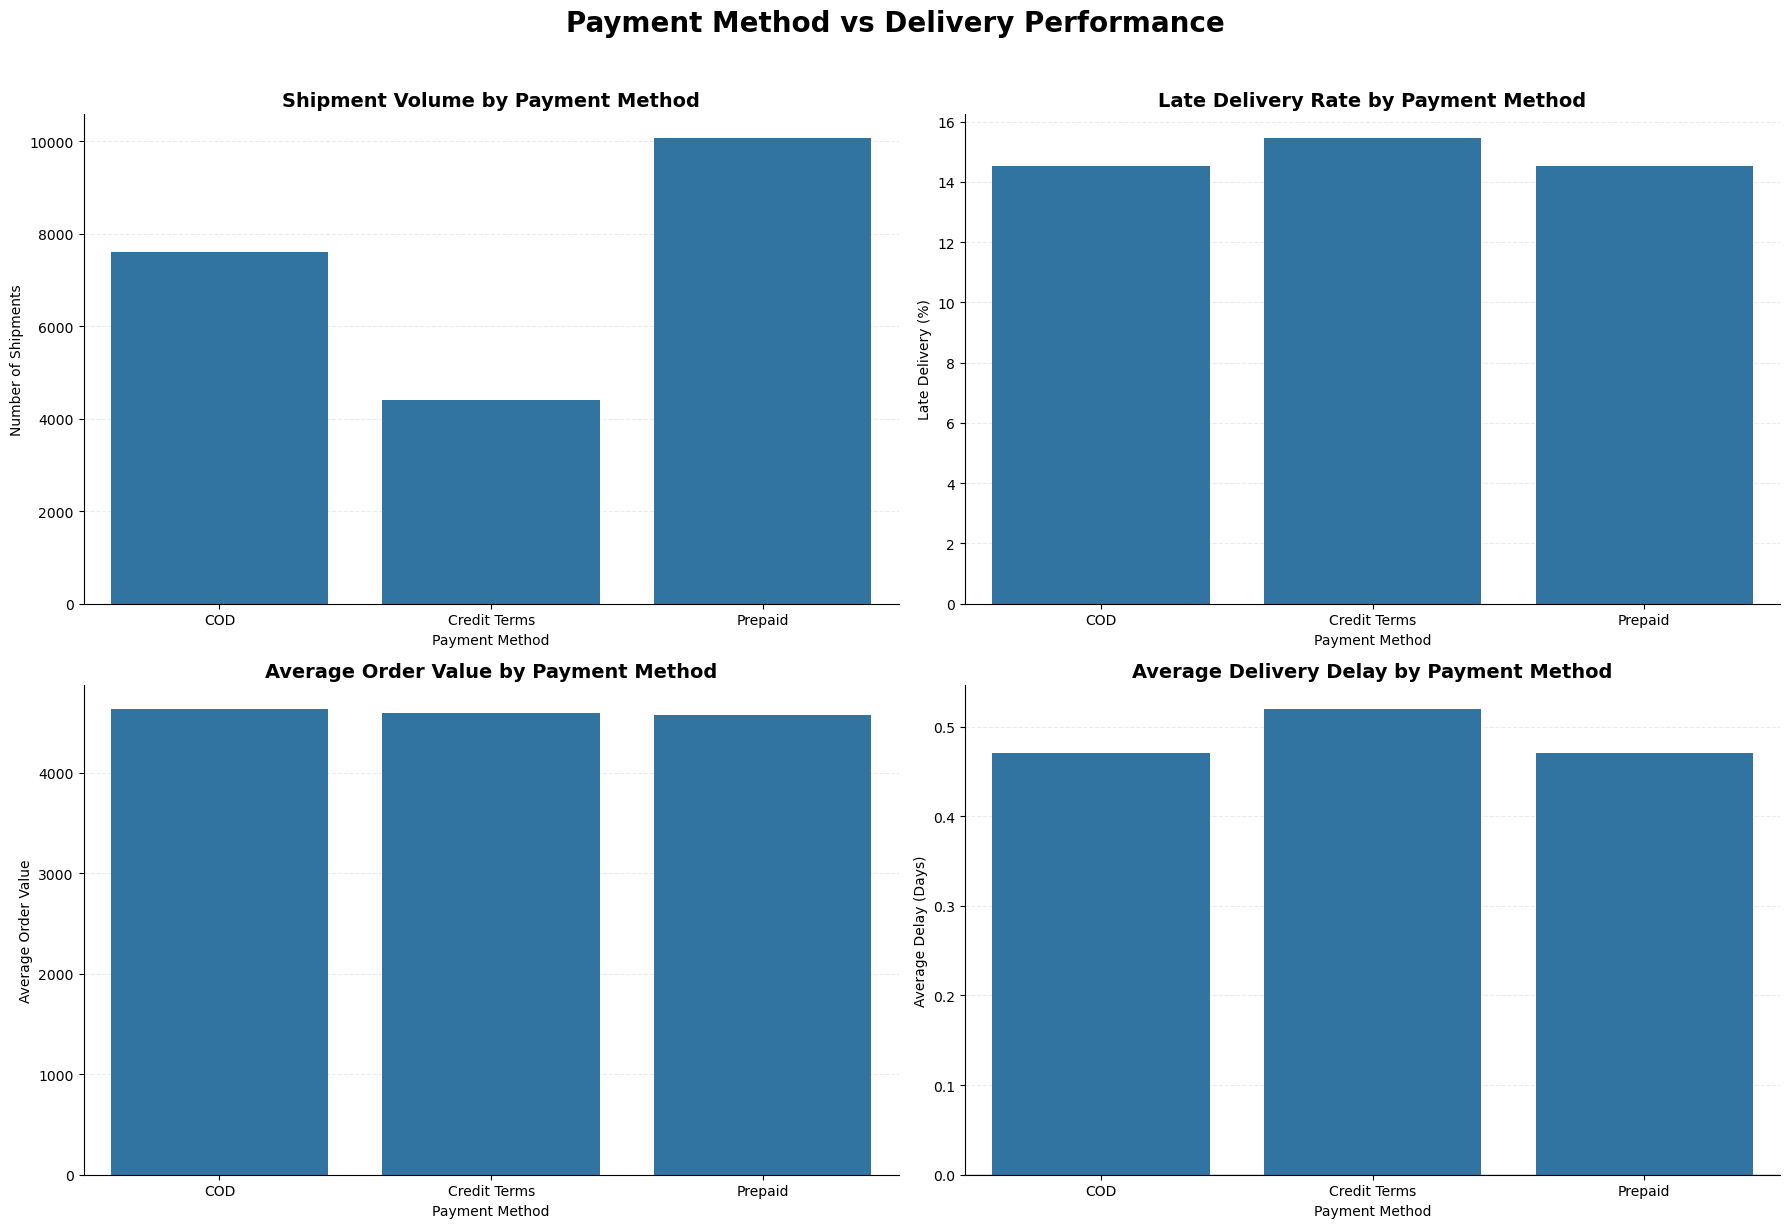

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Payment Method vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Shipment volume by payment method
sns.barplot(
    data=payment_summary,
    x="PaymentMethod",
    y="Total_Shipments",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Shipment Volume by Payment Method",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Payment Method")
axes[0, 0].set_ylabel("Number of Shipments")


# 2. Late delivery rate
sns.barplot(
    data=payment_summary,
    x="PaymentMethod",
    y="Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Payment Method",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Payment Method")
axes[0, 1].set_ylabel("Late Delivery (%)")


# 3. Average order value
sns.barplot(
    data=payment_summary,
    x="PaymentMethod",
    y="Avg_Order_Value",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Average Order Value by Payment Method",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Payment Method")
axes[1, 0].set_ylabel("Average Order Value")


# 4. Average delivery delay
sns.barplot(
    data=payment_summary,
    x="PaymentMethod",
    y="Avg_Delay_Days",
    ax=axes[1, 1]
)

axes[1, 1].axhline(0, linewidth=1)

axes[1, 1].set_title(
    "Average Delivery Delay by Payment Method",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Average Delay (Days)")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q16 — Distance × Shipping Priority vs Delivery Performance

#### Does the impact of route distance on late delivery vary by shipping priority? In other words, are long-distance shipments particularly sensitive to priority level?

In [78]:
# Create distance bands using quartiles
Fact_Shipments["Distance_Band"] = pd.qcut(
    Fact_Shipments["DistanceKm"],
    q=4,
    labels=["Short Distance", "Medium Distance", "Long Distance", "Very Long Distance"]
)

# Create summary table by distance and shipping priority
distance_priority_summary = (
    Fact_Shipments
    .groupby(["Distance_Band", "ShippingPriority"], observed=True)
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Distance_Km=("DistanceKm", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
distance_priority_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
distance_priority_summary = distance_priority_summary.round(2)

distance_priority_summary

,Distance_Band,ShippingPriority,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Distance_Km,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days
0,Short Distance,Express,1699,94,5.53,490.02,1.97,1.79,-0.18
1,Short Distance,Same-Day,549,62,11.29,501.09,1.00,1.66,0.66
2,Short Distance,Standard,3280,132,4.02,496.69,2.81,2.53,-0.27
3,Medium Distance,Express,1662,151,9.09,1041.42,2.68,2.75,0.06
4,Medium Distance,Same-Day,563,105,18.65,1041.05,1.00,2.14,1.14
5,Medium Distance,Standard,3304,257,7.78,1047.57,4.20,4.14,-0.06
6,Long Distance,Express,1673,326,19.49,1533.92,3.37,4.13,0.76
7,Long Distance,Same-Day,569,183,32.16,1541.93,1.00,3.05,2.05
8,Long Distance,Standard,3283,534,16.27,1535.78,5.38,5.89,0.51
9,Very Long Distance,Express,1699,445,26.19,2008.39,4.04,5.28,1.24


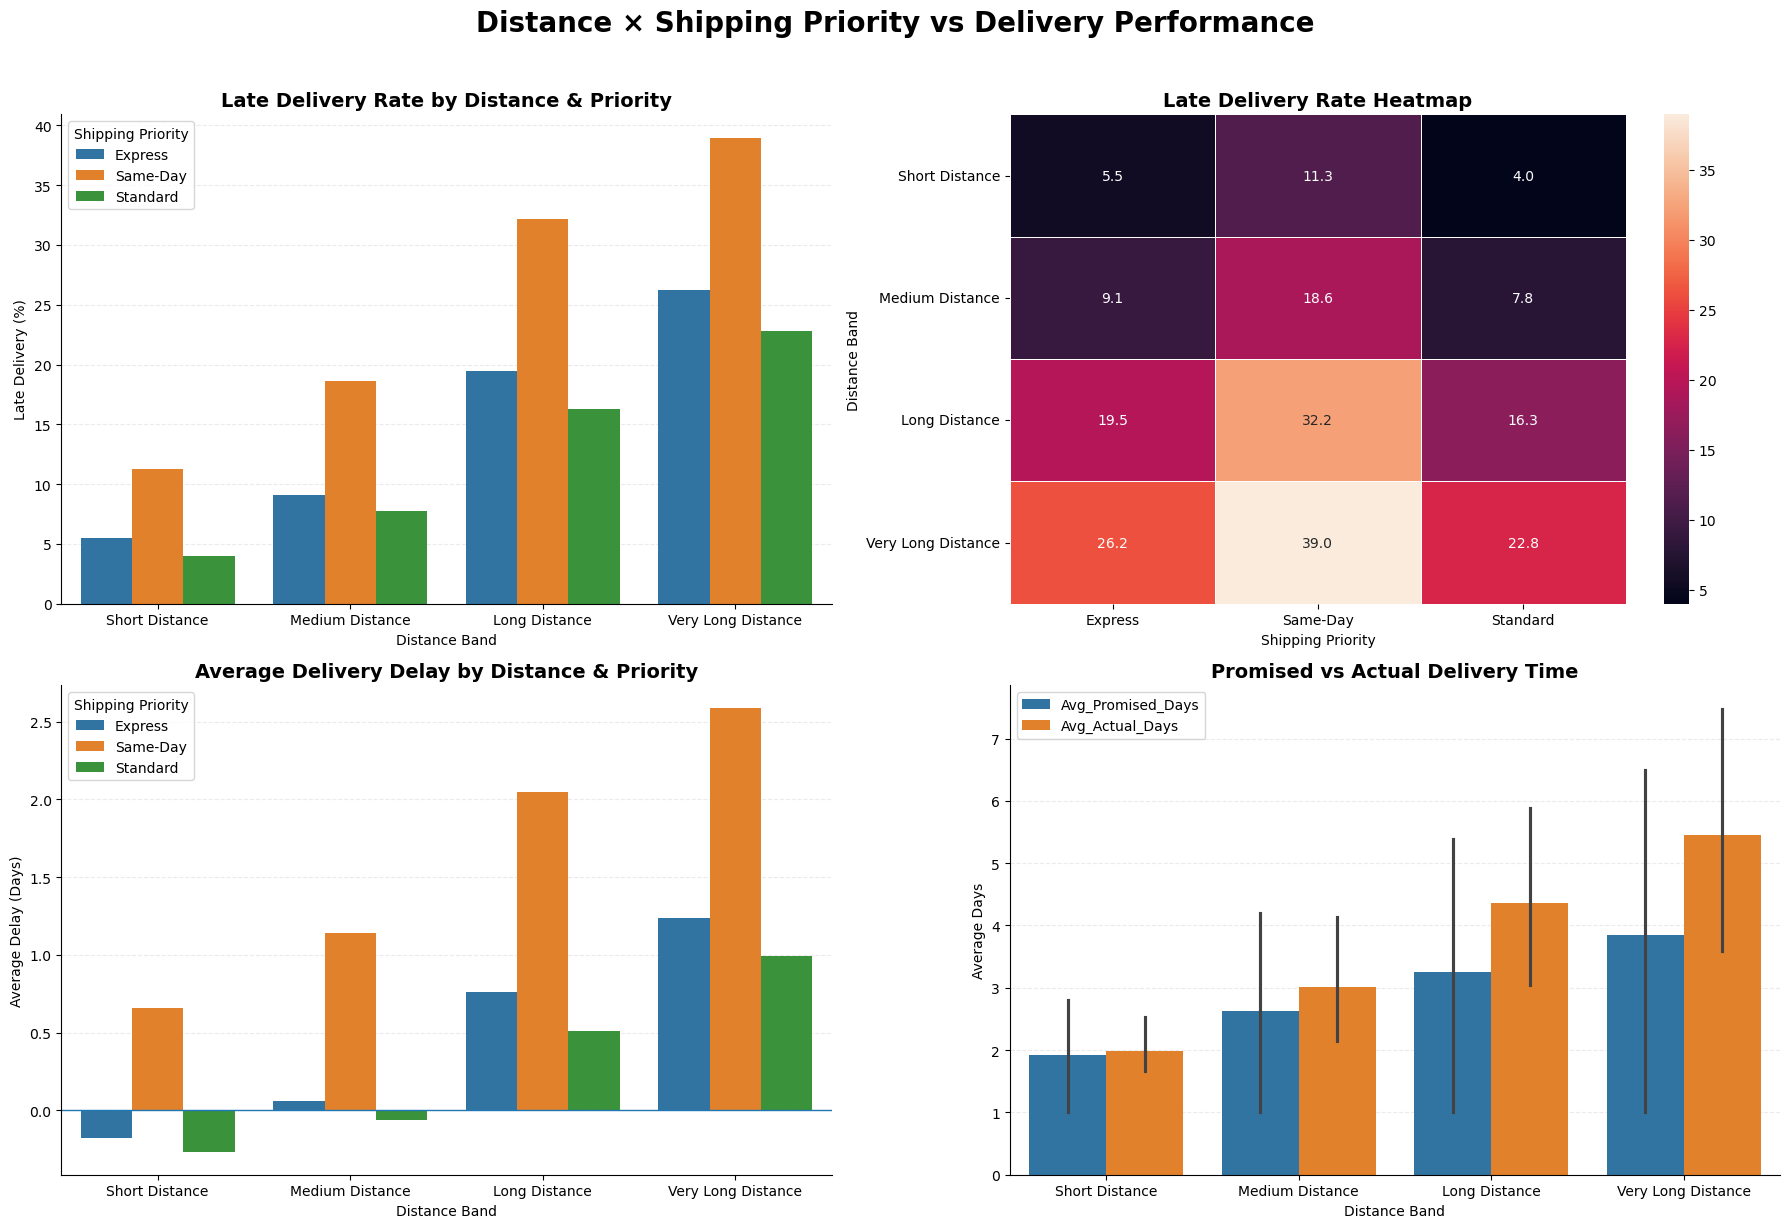

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Distance × Shipping Priority vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Late delivery rate by distance and priority
sns.barplot(
    data=distance_priority_summary,
    x="Distance_Band",
    y="Late_Delivery_Rate",
    hue="ShippingPriority",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Late Delivery Rate by Distance & Priority",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Distance Band")
axes[0, 0].set_ylabel("Late Delivery (%)")
axes[0, 0].legend(title="Shipping Priority")


# 2. Heatmap of late delivery rate
heatmap_data = distance_priority_summary.pivot(
    index="Distance_Band",
    columns="ShippingPriority",
    values="Late_Delivery_Rate"
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate Heatmap",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Shipping Priority")
axes[0, 1].set_ylabel("Distance Band")


# 3. Average delivery delay
sns.barplot(
    data=distance_priority_summary,
    x="Distance_Band",
    y="Avg_Delay_Days",
    hue="ShippingPriority",
    ax=axes[1, 0]
)

axes[1, 0].axhline(0, linewidth=1)

axes[1, 0].set_title(
    "Average Delivery Delay by Distance & Priority",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Distance Band")
axes[1, 0].set_ylabel("Average Delay (Days)")
axes[1, 0].legend(title="Shipping Priority")


# 4. Promised vs actual delivery days
plot_data = distance_priority_summary.melt(
    id_vars=["Distance_Band", "ShippingPriority"],
    value_vars=["Avg_Promised_Days", "Avg_Actual_Days"],
    var_name="Delivery_Type",
    value_name="Days"
)

sns.barplot(
    data=plot_data,
    x="Distance_Band",
    y="Days",
    hue="Delivery_Type",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Promised vs Actual Delivery Time",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Distance Band")
axes[1, 1].set_ylabel("Average Days")
axes[1, 1].legend(title="")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q17 — Vehicle Utilization vs Delivery Performance

#### Does the number of shipments handled by a vehicle relate to delivery performance, and do heavily utilized vehicles have higher late-delivery rates?

In [80]:
# Calculate the number of shipments handled by each vehicle
vehicle_utilization = (
    Fact_Shipments
    .groupby("VehicleID")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Divide vehicles into utilization bands based on shipment volume
vehicle_utilization["Utilization_Band"] = pd.qcut(
    vehicle_utilization["Total_Shipments"],
    q=4,
    labels=["Low Utilization", "Medium Utilization",
            "High Utilization", "Very High Utilization"]
)

# Create summary table by utilization band
vehicle_utilization_summary = (
    vehicle_utilization
    .groupby("Utilization_Band", observed=True)
    .agg(
        Vehicles=("VehicleID", "count"),
        Total_Shipments=("Total_Shipments", "sum"),
        Avg_Shipments_Per_Vehicle=("Total_Shipments", "mean"),
        Avg_Late_Delivery_Rate=("Late_Delivery_Rate", "mean"),
        Avg_Delivery_Days=("Avg_Delivery_Days", "mean"),
        Avg_Delay_Days=("Avg_Delay_Days", "mean")
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
vehicle_utilization_summary["Avg_Late_Delivery_Rate"] *= 100

# Round numerical values
vehicle_utilization_summary = vehicle_utilization_summary.round(2)

vehicle_utilization_summary

,Utilization_Band,Vehicles,Total_Shipments,Avg_Shipments_Per_Vehicle,Avg_Late_Delivery_Rate,Avg_Delivery_Days,Avg_Delay_Days
0,Low Utilization,136,4282,31.49,16.18,4.39,0.59
1,Medium Utilization,119,4699,39.49,14.19,4.25,0.46
2,High Utilization,125,5726,45.81,14.15,4.31,0.44
3,Very High Utilization,120,7403,61.69,14.81,4.30,0.47


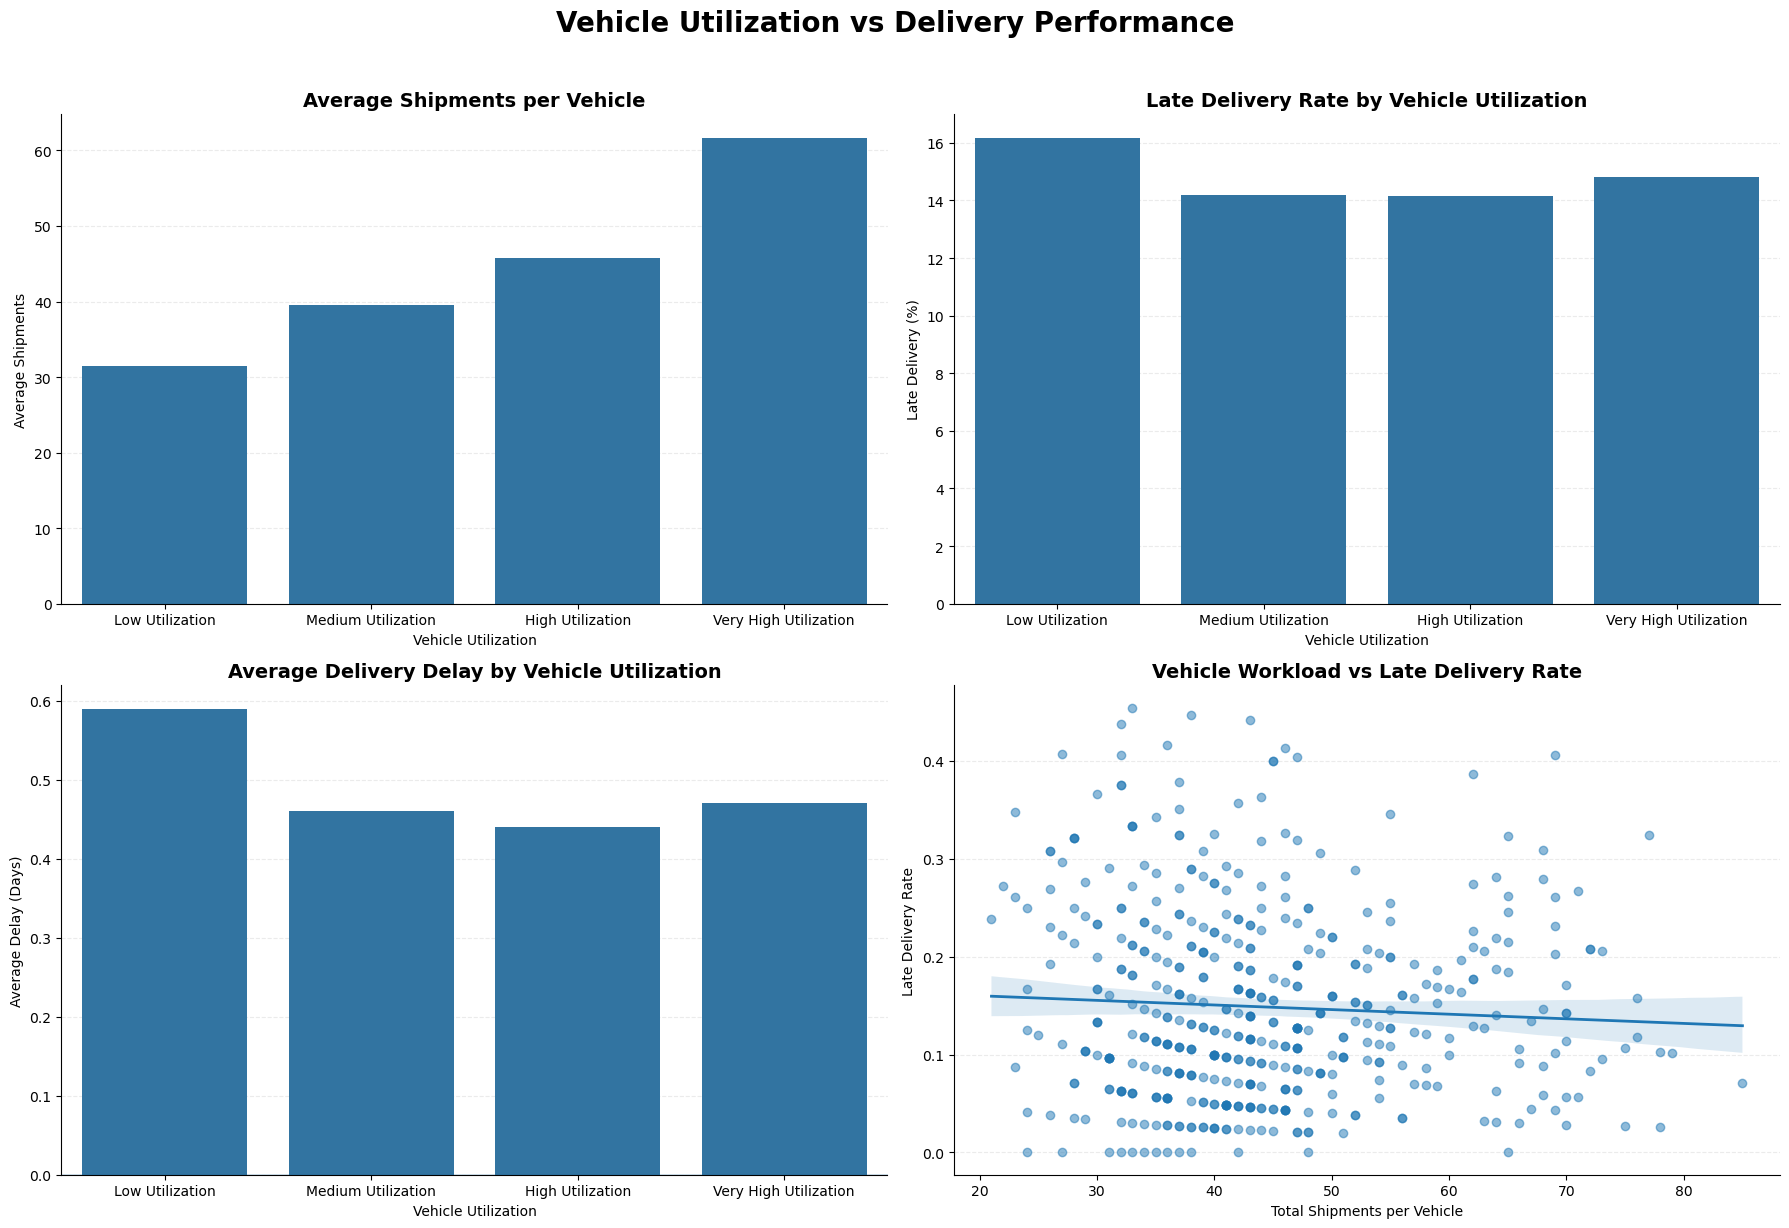

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Vehicle Utilization vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Average shipments per vehicle
sns.barplot(
    data=vehicle_utilization_summary,
    x="Utilization_Band",
    y="Avg_Shipments_Per_Vehicle",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Average Shipments per Vehicle",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Vehicle Utilization")
axes[0, 0].set_ylabel("Average Shipments")


# 2. Late delivery rate
sns.barplot(
    data=vehicle_utilization_summary,
    x="Utilization_Band",
    y="Avg_Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Vehicle Utilization",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Vehicle Utilization")
axes[0, 1].set_ylabel("Late Delivery (%)")


# 3. Average delivery delay
sns.barplot(
    data=vehicle_utilization_summary,
    x="Utilization_Band",
    y="Avg_Delay_Days",
    ax=axes[1, 0]
)

axes[1, 0].axhline(0, linewidth=1)

axes[1, 0].set_title(
    "Average Delivery Delay by Vehicle Utilization",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Vehicle Utilization")
axes[1, 0].set_ylabel("Average Delay (Days)")


# 4. Vehicle workload vs late delivery rate
sns.regplot(
    data=vehicle_utilization,
    x="Total_Shipments",
    y="Late_Delivery_Rate",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2},
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Vehicle Workload vs Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Total Shipments per Vehicle")
axes[1, 1].set_ylabel("Late Delivery Rate")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q18 — Route Performance vs Delivery Reliability

#### How does delivery performance vary across routes, and are certain routes consistently associated with higher delay rates or longer delivery times?

In [82]:
# Create route-level delivery performance summary
route_summary = (
    Fact_Shipments
    .groupby("RouteID")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Distance_Km=("DistanceKm", "mean"),
        Avg_Promised_Days=("PromisedDeliveryDays", "mean"),
        Avg_Actual_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        ),
        Delivery_Days_Std=("ActualDeliveryDays", "std")
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
route_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
route_summary = route_summary.round(2)

# Sort by shipment volume
route_summary = route_summary.sort_values(
    "Total_Shipments",
    ascending=False
).reset_index(drop=True)

route_summary

,RouteID,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Distance_Km,Avg_Promised_Days,Avg_Actual_Days,Avg_Delay_Days,Delivery_Days_Std
0,326,89,27,30.34,2048.61,5.34,6.61,1.27,3.49
1,162,88,3,3.41,495.82,2.45,2.27,-0.18,1.35
2,295,86,5,5.81,507.82,2.37,2.30,-0.07,1.42
3,341,82,4,4.88,1367.99,3.93,3.82,-0.11,1.96
4,101,82,17,20.73,1741.42,4.99,5.89,0.90,2.91
...,...,...,...,...,...,...,...,...,...
345,229,46,4,8.70,894.64,3.09,3.09,0.00,2.03
346,272,45,9,20.00,1517.59,4.07,5.02,0.96,3.03
347,14,45,10,22.22,1811.84,4.71,5.58,0.87,3.20
348,321,45,2,4.44,941.04,2.98,2.87,-0.11,1.93


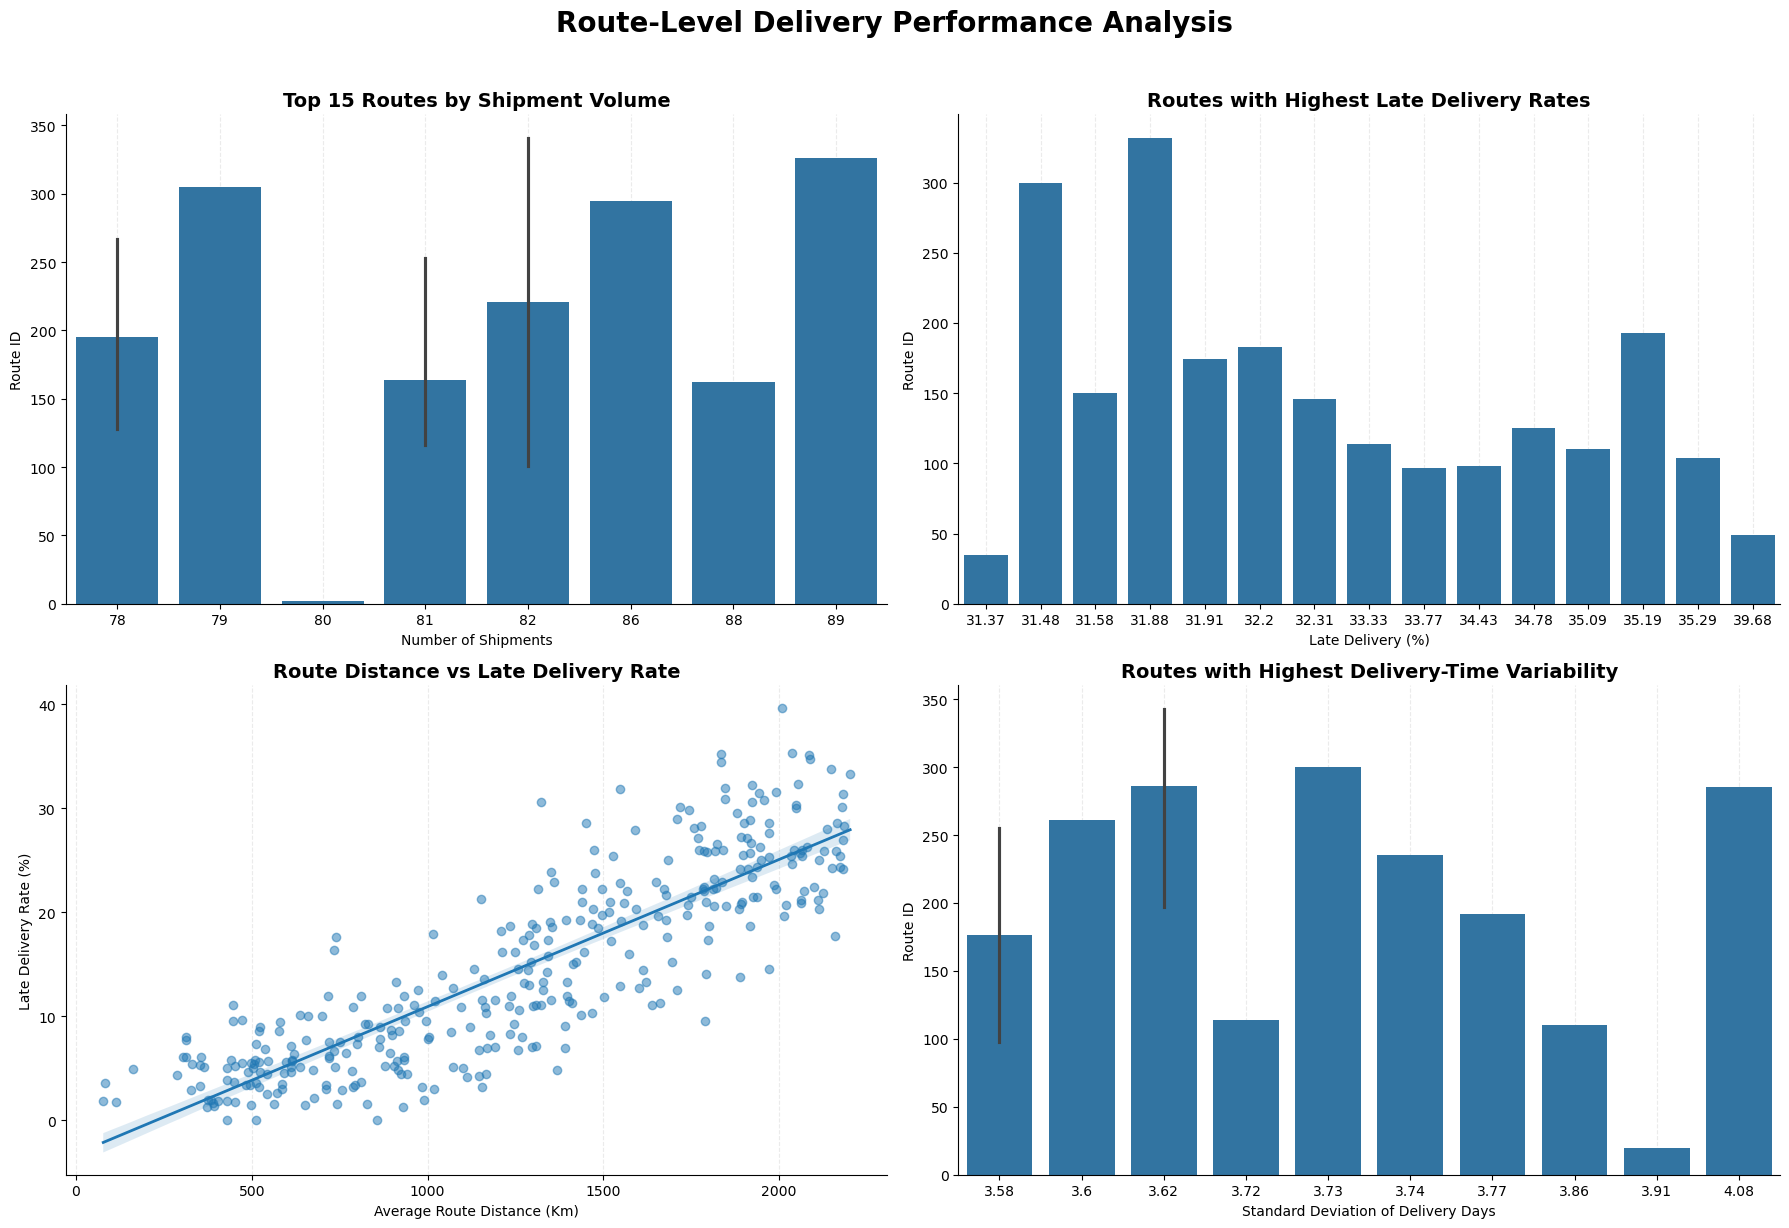

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Route-Level Delivery Performance Analysis",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Top 15 routes by shipment volume
top_routes = route_summary.nlargest(15, "Total_Shipments")

sns.barplot(
    data=top_routes.sort_values("Total_Shipments"),
    x="Total_Shipments",
    y="RouteID",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Top 15 Routes by Shipment Volume",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Number of Shipments")
axes[0, 0].set_ylabel("Route ID")


# 2. Top 15 routes by late-delivery rate
high_delay_routes = route_summary.nlargest(15, "Late_Delivery_Rate")

sns.barplot(
    data=high_delay_routes.sort_values("Late_Delivery_Rate"),
    x="Late_Delivery_Rate",
    y="RouteID",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Routes with Highest Late Delivery Rates",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Late Delivery (%)")
axes[0, 1].set_ylabel("Route ID")


# 3. Route distance vs late delivery rate
sns.regplot(
    data=route_summary,
    x="Avg_Distance_Km",
    y="Late_Delivery_Rate",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2},
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Route Distance vs Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Average Route Distance (Km)")
axes[1, 0].set_ylabel("Late Delivery Rate (%)")


# 4. Delivery time variability
top_variability_routes = route_summary.nlargest(
    15,
    "Delivery_Days_Std"
)

sns.barplot(
    data=top_variability_routes.sort_values("Delivery_Days_Std"),
    x="Delivery_Days_Std",
    y="RouteID",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Routes with Highest Delivery-Time Variability",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Standard Deviation of Delivery Days")
axes[1, 1].set_ylabel("Route ID")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q19 — Customer Segment vs Delivery Performance

#### Do customer characteristics and previous delivery experience relate to current delivery performance, and which customer segments show different levels of delivery reliability?

In [84]:
# Create customer-level delivery performance summary
customer_summary = (
    Fact_Shipments
    .groupby("CustomerID")
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Order_Value=("OrderValue", "mean"),
        Avg_Order_Quantity=("OrderQuantity", "mean"),
        Avg_Previous_Delays=("NumPreviousDelaysCustomer", "mean"),
        Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        )
    )
    .reset_index()
)

# Create customer shipment-volume segments
customer_summary["Customer_Segment"] = pd.qcut(
    customer_summary["Total_Shipments"],
    q=4,
    labels=[
        "Low Activity",
        "Medium Activity",
        "High Activity",
        "Very High Activity"
    ]
)

# Create segment-level summary
customer_segment_summary = (
    customer_summary
    .groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Shipments=("Total_Shipments", "mean"),
        Avg_Late_Delivery_Rate=("Late_Delivery_Rate", "mean"),
        Avg_Previous_Delays=("Avg_Previous_Delays", "mean"),
        Avg_Order_Value=("Avg_Order_Value", "mean"),
        Avg_Delivery_Days=("Avg_Delivery_Days", "mean"),
        Avg_Delay_Days=("Avg_Delay_Days", "mean")
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
customer_segment_summary["Avg_Late_Delivery_Rate"] *= 100

# Round numerical values
customer_segment_summary = customer_segment_summary.round(2)

customer_segment_summary

,Customer_Segment,Customers,Avg_Shipments,Avg_Late_Delivery_Rate,Avg_Previous_Delays,Avg_Order_Value,Avg_Delivery_Days,Avg_Delay_Days
0,Low Activity,766,4.06,14.85,1.18,4574.64,4.35,0.47
1,Medium Activity,852,6.48,15.00,1.22,4652.22,4.34,0.50
2,High Activity,732,8.47,14.28,1.21,4562.53,4.27,0.45
3,Very High Activity,646,11.27,14.78,1.21,4613.87,4.28,0.49


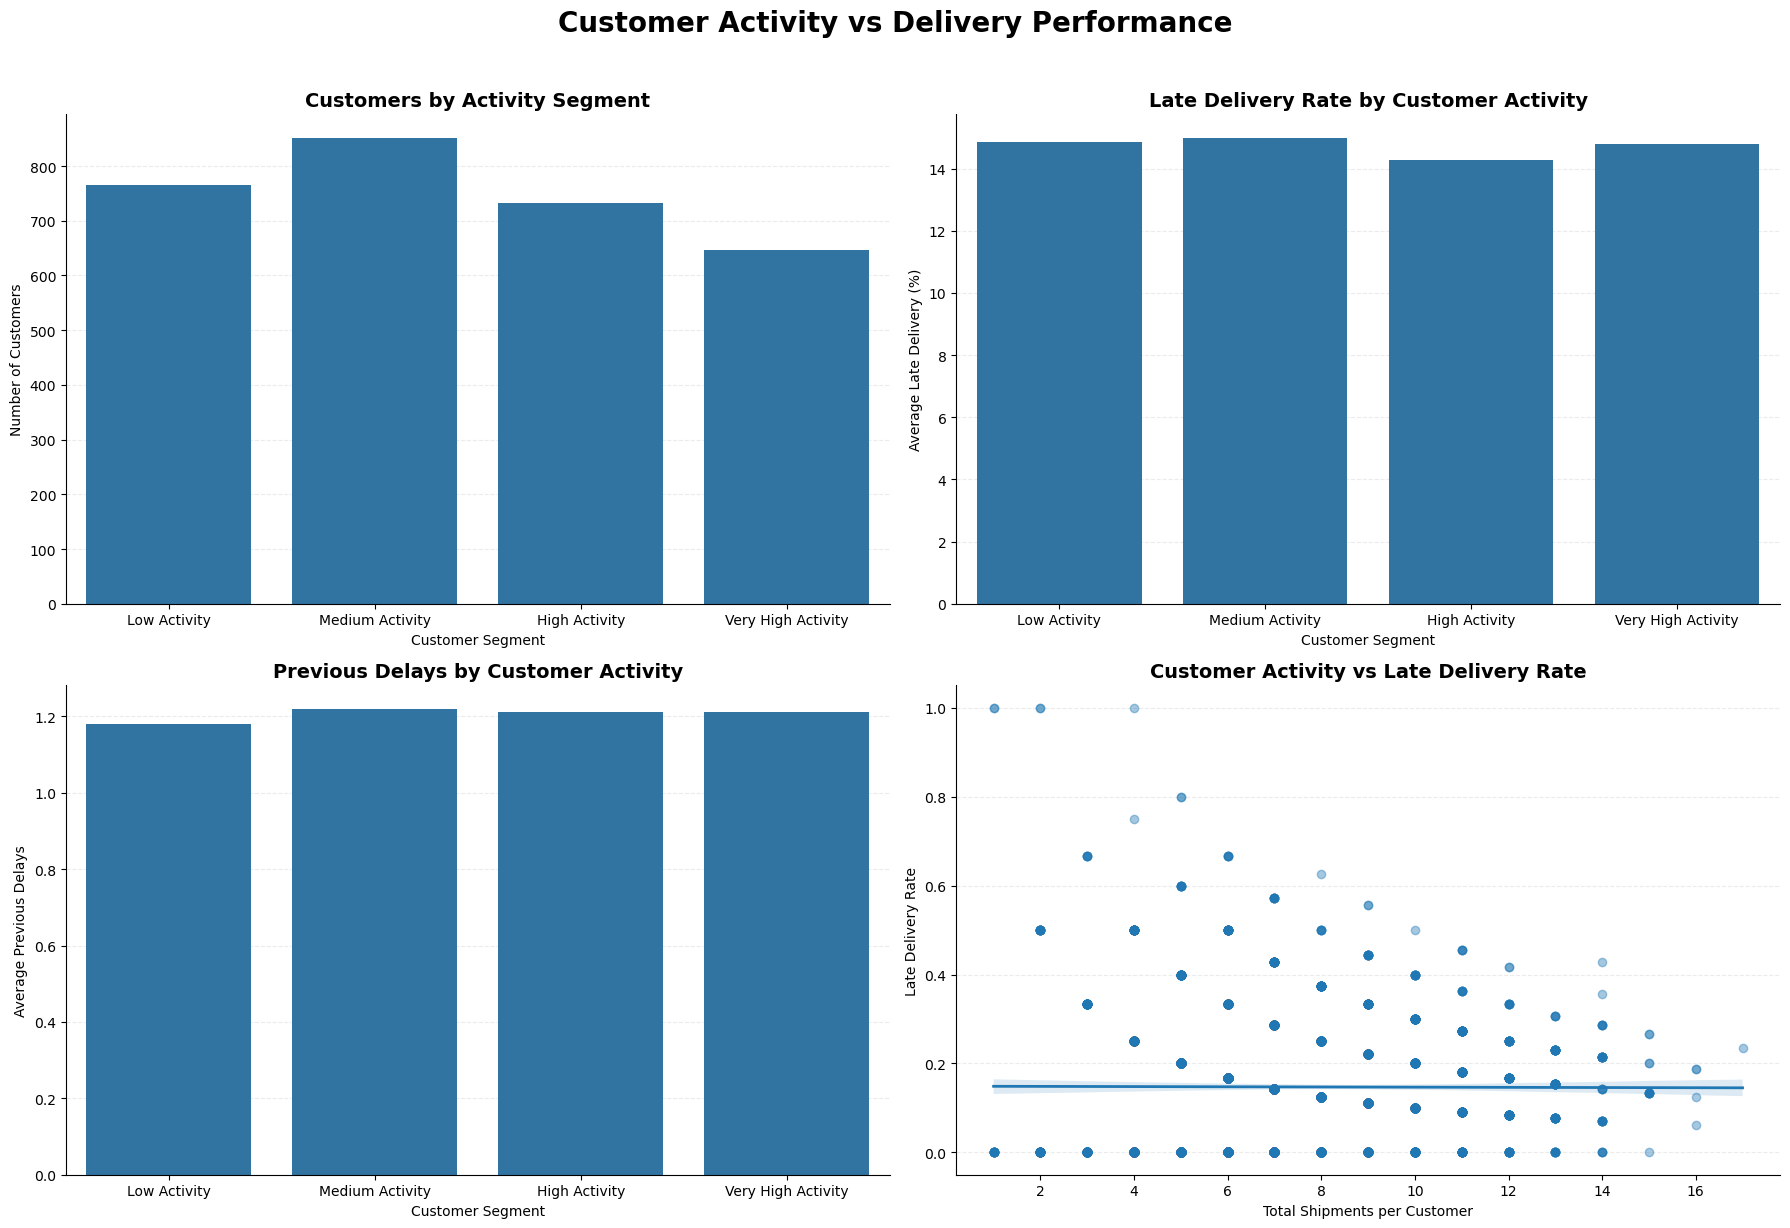

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Customer Activity vs Delivery Performance",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Customers in each activity segment
sns.barplot(
    data=customer_segment_summary,
    x="Customer_Segment",
    y="Customers",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Customers by Activity Segment",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Customer Segment")
axes[0, 0].set_ylabel("Number of Customers")


# 2. Late delivery rate
sns.barplot(
    data=customer_segment_summary,
    x="Customer_Segment",
    y="Avg_Late_Delivery_Rate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Late Delivery Rate by Customer Activity",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Customer Segment")
axes[0, 1].set_ylabel("Average Late Delivery (%)")


# 3. Previous delays
sns.barplot(
    data=customer_segment_summary,
    x="Customer_Segment",
    y="Avg_Previous_Delays",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Previous Delays by Customer Activity",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Customer Segment")
axes[1, 0].set_ylabel("Average Previous Delays")


# 4. Customer activity vs late delivery rate
sns.regplot(
    data=customer_summary,
    x="Total_Shipments",
    y="Late_Delivery_Rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"linewidth": 2},
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Customer Activity vs Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Total Shipments per Customer")
axes[1, 1].set_ylabel("Late Delivery Rate")


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

######
# Q20 — Delivery Risk by Combined Operational Factors

#### Which combinations of traffic condition, weather condition, and shipping priority are associated with the highest delivery risk?

In [86]:
# Create combined operational risk summary
risk_summary = (
    Fact_Shipments
    .groupby(
        ["TrafficCondition", "WeatherCondition", "ShippingPriority"],
        observed=True
    )
    .agg(
        Total_Shipments=("ShipmentID", "count"),
        Late_Shipments=("Late_Delivery", "sum"),
        Late_Delivery_Rate=("Late_Delivery", "mean"),
        Avg_Delivery_Days=("ActualDeliveryDays", "mean"),
        Avg_Delay_Days=("ActualDeliveryDays",
            lambda x: (
                x - Fact_Shipments.loc[x.index, "PromisedDeliveryDays"]
            ).mean()
        ),
        Avg_Distance_Km=("DistanceKm", "mean")
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
risk_summary["Late_Delivery_Rate"] *= 100

# Round numerical values
risk_summary = risk_summary.round(2)

# Sort by late-delivery rate
risk_summary = risk_summary.sort_values(
    "Late_Delivery_Rate",
    ascending=False
).reset_index(drop=True)

risk_summary

,TrafficCondition,WeatherCondition,ShippingPriority,Total_Shipments,Late_Shipments,Late_Delivery_Rate,Avg_Delivery_Days,Avg_Delay_Days,Avg_Distance_Km
0,HIGH,Extreme Heat,Same-Day,1,1,100.00,9.00,8.00,2229.50
1,HIGH,Storm,Express,2,2,100.00,10.00,6.50,1883.85
2,High,Storm,Same-Day,37,28,75.68,6.43,5.43,1154.07
3,LOW,Fog,Same-Day,3,2,66.67,5.33,4.33,1583.53
4,HIGH,Storm,Standard,3,2,66.67,7.00,2.67,1100.57
...,...,...,...,...,...,...,...,...,...
78,LOW,Fog,Standard,7,0,0.00,3.57,-0.29,974.63
79,med,Extreme Heat,Standard,8,0,0.00,4.00,-0.75,1224.19
80,med,Fog,Standard,9,0,0.00,3.67,-0.56,1082.80
81,med,Rain,Same-Day,2,0,0.00,1.00,0.00,1203.15


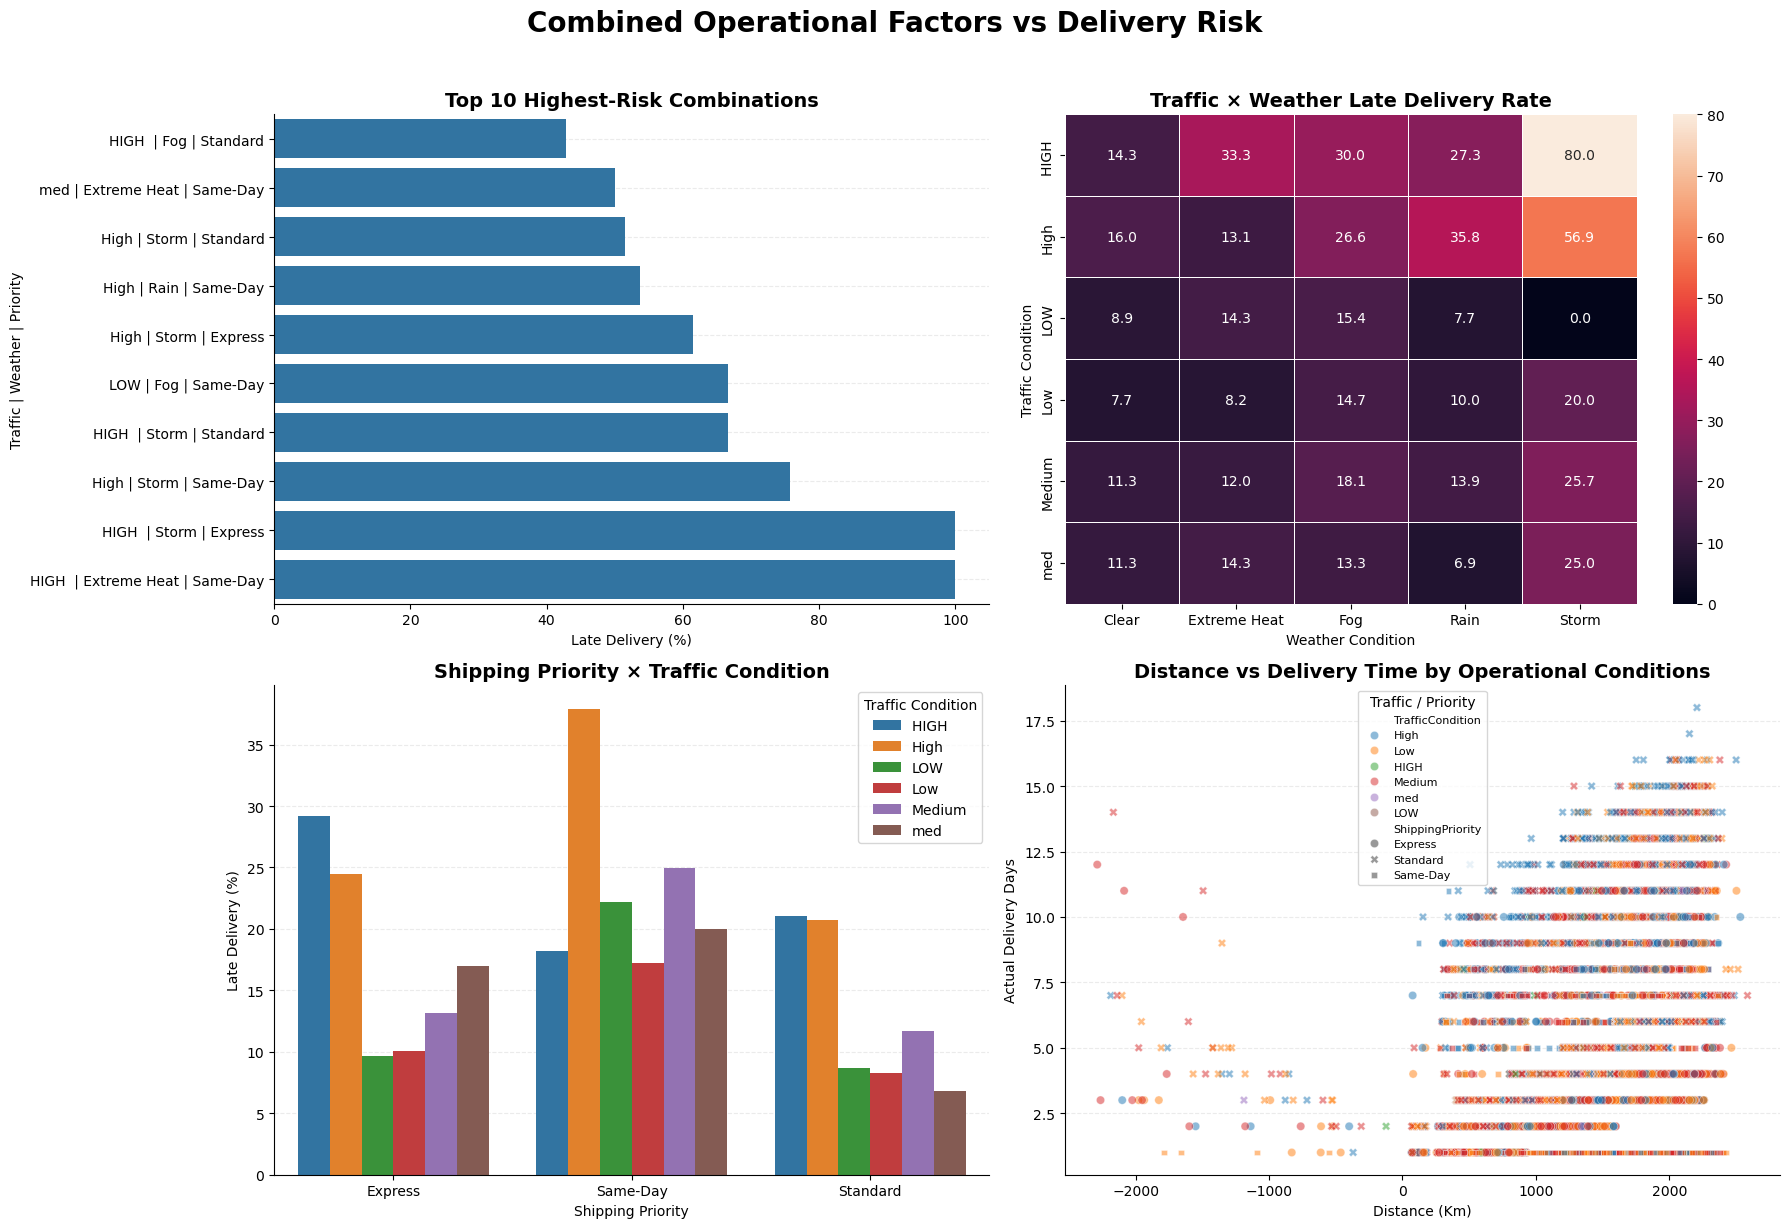

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Combined Operational Factors vs Delivery Risk",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

# 1. Top 10 highest-risk combinations
top_risk = risk_summary.nlargest(10, "Late_Delivery_Rate").copy()

top_risk["Condition"] = (
    top_risk["TrafficCondition"].astype(str)
    + " | "
    + top_risk["WeatherCondition"].astype(str)
    + " | "
    + top_risk["ShippingPriority"].astype(str)
)

sns.barplot(
    data=top_risk.sort_values("Late_Delivery_Rate"),
    x="Late_Delivery_Rate",
    y="Condition",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Top 10 Highest-Risk Combinations",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Late Delivery (%)")
axes[0, 0].set_ylabel("Traffic | Weather | Priority")


# 2. Traffic × Weather heatmap
traffic_weather = (
    Fact_Shipments
    .groupby(
        ["TrafficCondition", "WeatherCondition"],
        observed=True
    )["Late_Delivery"]
    .mean()
    .mul(100)
    .reset_index()
)

heatmap_data = traffic_weather.pivot(
    index="TrafficCondition",
    columns="WeatherCondition",
    values="Late_Delivery"
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Traffic × Weather Late Delivery Rate",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Weather Condition")
axes[0, 1].set_ylabel("Traffic Condition")


# 3. Shipping priority × traffic
priority_traffic = (
    Fact_Shipments
    .groupby(
        ["ShippingPriority", "TrafficCondition"],
        observed=True
    )["Late_Delivery"]
    .mean()
    .mul(100)
    .reset_index()
)

sns.barplot(
    data=priority_traffic,
    x="ShippingPriority",
    y="Late_Delivery",
    hue="TrafficCondition",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Shipping Priority × Traffic Condition",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Shipping Priority")
axes[1, 0].set_ylabel("Late Delivery (%)")
axes[1, 0].legend(title="Traffic Condition")


# 4. Distance vs delay under operational conditions
sns.scatterplot(
    data=Fact_Shipments,
    x="DistanceKm",
    y="ActualDeliveryDays",
    hue="TrafficCondition",
    style="ShippingPriority",
    alpha=0.5,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Distance vs Delivery Time by Operational Conditions",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Distance (Km)")
axes[1, 1].set_ylabel("Actual Delivery Days")
axes[1, 1].legend(
    title="Traffic / Priority",
    fontsize=8
)


# Clean up all subplots
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ---------------------------------------- THE END ----------------------------------------